In [1]:
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from sympy import symbols, sqrt, lambdify, sympify
from sympy import Poly, solve
from sympy import simplify, expand, factor, collect
from colorama import Fore, Back, Style

### Parameters setting

### Toni's paper

In [2]:
##q = 0.11
#theta = 5
lambda_, alpha, pH, q, theta, pL = symbols('lambda alpha pH q theta pL',  real=True, positive=True)
e = 1.025*q*lambda_*theta
tcL = 0.02
tcH = 0.02
#Interest rate for L-sellers under SEPARATING contract
rL_S =(1-lambda_)*pL
rH_S = pL
S_Sep = alpha*q*(pH - rH_S + lambda_*theta) + (1 - alpha)*q*(pL-rH_S + lambda_*theta) + (1-q)*(pL - rL_S) 
S_Sep = simplify(expand(S_Sep))
B_Sep = q*(rH_S - 1) +(1 - q)*(rL_S - 1) + q*((1-lambda_)*theta -1)
B_Sep = simplify(expand(B_Sep))
#Interest rate for L-sellers under PARTIAL POOLING contract
rL_P =(1-lambda_)*pL
rH_P = rL_P + theta*lambda_
S_PP = alpha*q*(pH - rH_P + theta*lambda_) + (1 - alpha*q)*(pL- rL_P)
B_PP = alpha*q*(rH_P - 1) + (1 - alpha*q)*(rL_P-1) + alpha*q*((1-lambda_)*theta-1)
S_PP = simplify(expand(S_PP))
B_PP = simplify(expand(B_PP))
#Interest rate for L-sellers under DEPOSIT contract
rL_D =(1-lambda_)*pL 
rH_D = (1-lambda_)*pH + theta*lambda_
S_Dep = q*(pH - rH_D +lambda_*theta) +(1-q)*(pL - rL_D)
S_Dep = simplify(expand(S_Dep))
#Interest rate for L-sellers under STABLECOIN contract
rL_St = (1-tcL)*(1-lambda_)*pL 
rH_St = rL_St + theta*lambda_
S_St = q*((1-tcH)*pH - rH_St + theta*lambda_)+ (1 - q)*((1-tcL)*pL - rL_St)

#### Function that check values of two payoffs for smaller lambda value than the threshold, cannot simplify for some reason. You decide whether the result is lower

In [2]:

def check_smaller_lambda(ex1, ex2):
    lambda_s = solve(ex1- ex2, lambda_)
    if len(lambda_s) >1:
        print("There are two values of lambda that make the two payoff equal")
    else:
        lambda_s=simplify(lambda_s[0])
        print("The threshold is", lambda_s, ". Enter the value lower than this")
        x = input()
        a = simplify(expand(x))
        ex1 = ex1.subs([(lambda_, a)])
        ex2 = ex2.subs([(lambda_, a)])
        dif = simplify(expand(ex1)) - simplify(expand(ex2))
        dif1 = simplify(factor(factor(expand(dif)))) #calculate the difference between the two payoffs with the input value to check which payoff is larger
        print("The difference between the two payoffs is ", dif1, ". Would you like to simplify more? (yes/no)") #If the dif is False, i.e negative, the first payoff is smaller
        z = input()
        if z.lower() == "no":
            print("Gud. Is it positive?")
            w = input()
            if w.lower() == "yes":
                print("The first method returns higher payoff than the second method when lambda is lower than the threshold. Choose the first one")
            else:
                print("The first method returns lower payoff than the second method when lambda is lower than the threshold. CHoose the second one")
        else:
            dif2 = simplify(dif1)
            print("The difference between the two payoffs is ", dif2, ". Is it positive? (yes/no)")
            y = input()
            if y.lower() == "yes":
                print("The first method returns higher payoff than the second method when lambda is lower than the threshold. Choose the first one")
            else:
                print("The first method returns lower payoff than the second method when lambda is lower than the threshold. CHoose the second one")

#### To confirm the payoff in Toni's paper:

#### Define the lambda threshold from Toni's paper

In [5]:
#Solve for lambda and you need to see if there is only one unique solution
lambda_1 = solve(B_Sep - B_PP, lambda_)
#Solution from the paper
lambda_1p=(1-alpha)*(theta-1)/(theta-pL)
lambda_2p= alpha*(pH - pL)/(pH - theta)
#threshold for seller
lambda_2 = simplify(solve(S_Sep - S_Dep, lambda_)[0])
lambda_3 = simplify(solve(S_PP - S_Dep, lambda_)[0])
print(lambda_1)
print(lambda_2)
print(lambda_3)

[(alpha*theta - alpha - theta + 1)/(pL - theta)]
alpha*(pH - pL)/(pH - theta)
alpha


In [3]:
def solve_for_lambda(ex1, ex2):
    lambda_s = solve(ex1 - ex2, lambda_)
    if len(lambda_s) >1:
        print("There are more than 1 lambda that make the two payoff equal and they are ", lambda_s)
    else:
        lambda_s_1 = simplify(lambda_s[0])
        print("The threshold is ", lambda_s_1)

### Check whether the equation return one result

In [7]:
solve_for_lambda(B_Sep, B_PP)
solve_for_lambda(S_Sep, S_Dep)
solve_for_lambda(S_PP, S_Dep)

The threshold is  (alpha*theta - alpha - theta + 1)/(pL - theta)
The threshold is  alpha*(pH - pL)/(pH - theta)
The threshold is  alpha


#### If there is only one unique solution, set the three baseline lambda thresholds, also confirm them with the threshold in Toni's paper

In [8]:
lambda_1 = solve(B_Sep - B_PP, lambda_)[0]
lambda_2 = simplify(solve(S_Sep - S_Dep, lambda_)[0])
lambda_3 = solve(S_PP - S_Dep, lambda_)[0]

print(lambda_2)
simplify(lambda_2 - lambda_2p)==0

alpha*(pH - pL)/(pH - theta)


True

#### Do NOT rerun the following codes UNLESS the formula/variables have changed. These codes are to check which payoff is higher for a lower value of the threshold

#### Compare between the bank's payoffs of Separating contract and Partial Pooling contract

In [36]:
check_smaller_lambda(B_Sep, B_PP)

The threshold is (alpha*theta - alpha - theta + 1)/(pL - theta) . Enter the value lower than this
(alpha*theta - alpha - theta + 1.1)/(pL - theta)
The difference between the two payoffs is  1.0*q*(-1.0*alpha*pL*theta + 1.0*alpha*pL + 1.0*alpha*theta*theta - 1.0*alpha*theta + 1.0*alpha*pL*theta - 1.0*alpha*pL - 1.0*alpha*theta*theta + 1.0*alpha*theta - 1.0*pL*theta + 1.1*pL + 1.0*pL*theta - 1.0*pL - 1.1*theta + 1.0*theta)/(pL - theta) . Would you like to simplify more? (yes/no)
yes
The difference between the two payoffs is  1.0*q*(-1.0*alpha*pL*theta + 1.0*alpha*pL + 1.0*alpha*theta*theta - 1.0*alpha*theta + 1.0*alpha*pL*theta - 1.0*alpha*pL - 1.0*alpha*theta*theta + 1.0*alpha*theta - 1.0*pL*theta + 1.1*pL + 1.0*pL*theta - 1.0*pL - 1.1*theta + 1.0*theta)/(pL - theta) . Is it positive? (yes/no)
yes
The first method returns higher payoff than the second method when lambda is lower than the threshold. Choose the first one


In [53]:
a = 1.0*q*(-1.0*alpha*pL*theta + 1.0*alpha*pL + 1.0*alpha*theta*theta - 1.0*alpha*theta + 1.0*alpha*pL*theta - 1.0*alpha*pL - 1.0*alpha*theta*theta + 1.0*alpha*theta - 1.0*pL*theta + 1.1*pL + 1.0*pL*theta - 1.0*pL - 1.1*theta + 1.0*theta)/(pL - theta)
simplify(a)

0.1*q

#### Compare between the seller's payoffs of Separating contract and Banking Deposit contract

In [39]:
check_smaller_lambda(S_Sep, S_Dep)

The threshold is alpha*(pH - pL)/(pH - theta) . Enter the value lower than this
alpha*(pH - pL - 0.1)/(pH - theta)
The difference between the two payoffs is  1.0*q*(1.0*alpha*pH*pH - 1.0*alpha*pH*theta - 1.0*alpha*pH*pL + 1.0*alpha*pL*theta - 1.0*alpha*pH*pH + 1.0*alpha*pH*pL + 0.1*alpha*pH + 1.0*alpha*pH*theta - 1.0*alpha*pL*theta - 0.1*alpha*theta)/(pH - theta) . Would you like to simplify more? (yes/no)
yes
The difference between the two payoffs is  1.0*q*(1.0*alpha*pH*pH - 1.0*alpha*pH*theta - 1.0*alpha*pH*pL + 1.0*alpha*pL*theta - 1.0*alpha*pH*pH + 1.0*alpha*pH*pL + 0.1*alpha*pH + 1.0*alpha*pH*theta - 1.0*alpha*pL*theta - 0.1*alpha*theta)/(pH - theta) . Is it positive? (yes/no)
yes
The first method returns higher payoff than the second method when lambda is lower than the threshold. Choose the first one


In [38]:
a_1 = 1.0*q*(1.0*alpha*pH*pH - 1.0*alpha*pH*theta - 1.0*alpha*pH*pL + 1.0*alpha*pL*theta - 1.0*alpha*pH*pH + 1.0*alpha*pH*pL + 0.1*alpha*pH + 1.0*alpha*pH*theta - 1.0*alpha*pL*theta - 0.1*alpha*theta)/(pH - theta)
print(simplify(a_1))

0.1*alpha*q


#### Compare between the seller's payoffs of Partial Pooling contract and Banking Deposit

In [73]:
check_smaller_lambda(S_PP, S_Dep)

The threshold is alpha . Enter the value lower than this
alpha-0.1
The difference between the two payoffs is  1.0*q*(pH - pL)*(1.0*alpha - 1.0*alpha + 0.1) . Would you like to simplify more? (yes/no)
no
Gud. Is it positive?
yes
The first method returns higher payoff than the second method when lambda is lower than the threshold. Choose the first one


In [9]:
([pH_c, ph_c, q_c, theta_c, pL_c])= ([6, 0, 0.11, 5, 2.5])

def make_graph(eq1,eq2,eq3,a):
    plt.figure(figsize=(14, 10))
    x = np.linspace(0,1,num=100)
    y = np.linspace(a, 1,num=100)
    lambda_1 = lambdify(['alpha'], eq1.subs([(pH, pH_c), (ph, ph_c), (q, q_c), (theta, theta_c), (pL, pL_c)]))
    lambda_2 = lambdify(['alpha'], eq2.subs([(pH, pH_c), (ph, ph_c), (q, q_c), (theta, theta_c), (pL, pL_c)]))
    lambda_3 = lambdify(['alpha'], eq3.subs([(pH, pH_c), (ph, ph_c), (q, q_c), (theta, theta_c), (pL, pL_c)]))    
    plt.plot(x, lambda_1(x), 'k')
    plt.plot(x, lambda_2(x), 'b')
    plt.plot(y, lambda_3(y), 'r')
    plt.xlabel( r"$\alpha_0$, probability of matching with H-buyer ",fontsize=18)
    plt.ylabel(r'$\lambda$, Absconding payoff', fontsize=18)
    plt.title(r'Equilibrium map in $(\alpha, \lambda)$', fontsize=18)
    plt.axis([0, 1, 0, 0.8])

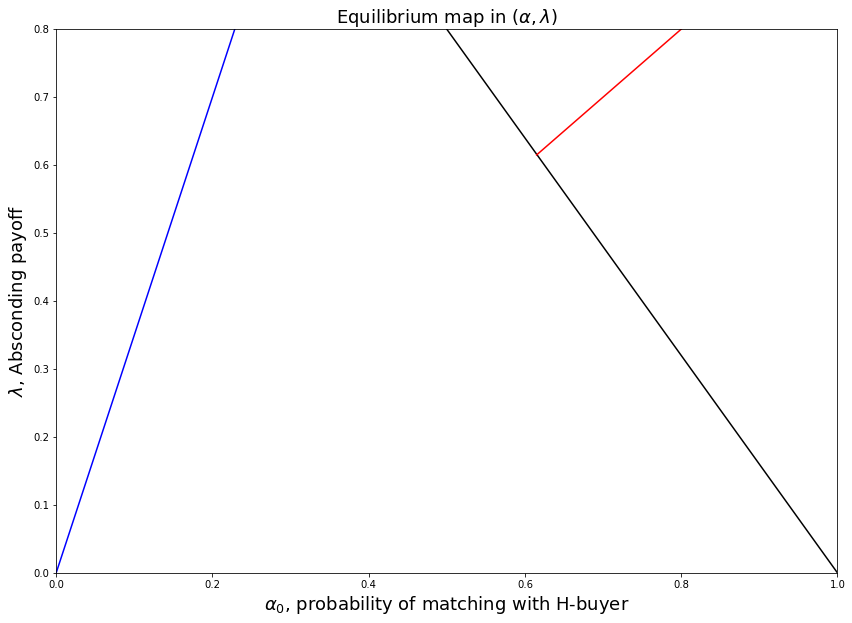

In [94]:
make_graph(lambda_1, lambda_2, lambda_3, 0.615)

### MY PAPER

In [4]:
#Basic paramets
([sigma_c, uH_c, q_c, theta_c, u_c, tcL_c, tcH_c])= ([0.4, 12, 0.2, 4, 8, 0.05, 0.05])
sigma, uH, q, theta, u, lambda_, alpha, tcL, tcH = symbols('sigma uH q theta u lambda alpha tcL tcH ',  real=True, positive=True)
e = 1.025*q*lambda_*theta


#Prices and interests
pH = (1-sigma)*uH+sigma*lambda_ - sigma*(theta-1)
ph = (1-sigma)*u+sigma*lambda_ - sigma*(theta-1)
pL = (1-sigma)*u+sigma*lambda_ 

#Interest rate for L-sellers under SEPARATING contract
rL_S =(1-lambda_)*ph
rH_S = rL_S + theta*lambda_
S_Sep = alpha*q*(pH - rH_S + lambda_*theta) + (1 - alpha)*q*(ph-rH_S + lambda_*theta) + (1-q)*(pL - rL_S) 
S_Sep = simplify(expand(S_Sep))
B_Sep = q*(rH_S - 1) +(1 - q)*(rL_S - 1) + q*((1-lambda_)*theta -1)
B_Sep = simplify(expand(B_Sep))
#Interest rate for L-sellers under PARTIAL POOLING contract
rL_P =(1-lambda_)*pL
rH_P = rL_P + theta*lambda_
S_PP = alpha*q*(pH - rH_P + theta*lambda_) + (1 - alpha*q)*(pL- rL_P)
B_PP = alpha*q*(rH_P - 1) + (1 - alpha*q)*(rL_P-1) + alpha*q*((1-lambda_)*theta-1)
S_PP = simplify(expand(S_PP))
B_PP = simplify(expand(B_PP))
#Interest rate for L-sellers under DEPOSIT contract
rL_D =(1-lambda_)*pL + e
rH_D = (1-lambda_)*pH + e
S_Dep = q*(pH - rH_D+lambda_*theta) +(1-q)*(pL - rL_D)
S_Dep = simplify(expand(S_Dep))
B_Dep = q*(rH_D - 1) + (1 - q)*(rL_D-1) + q*((1-lambda_)*theta-1)
#Interest rate for L-sellers under STABLECOIN contract
rL_St = (1-tcL)*(1-lambda_)*pL 
rH_St = rL_St + theta*lambda_
S_St = q*((1-tcH)*pH - rH_St + theta*lambda_)+ (1 - q)*((1-tcL)*pL - rL_St)
B_St = q*(rH_St - 1) + (1 - q)*(rL_St-1) + q*((1-lambda_)*theta-1)
#PARTIAL PARTICIPATION CONTRACT
r_PaPa = (1 - lambda_)*pH + lambda_*theta
B_PaPa = q*alpha*(r_PaPa - 1) +(1 - q*alpha)*(-1)+alpha*q*((1-lambda_)*theta-1)
B_PaPa = factor(simplify(factor(B_PaPa)))

#### The lending bank's payoff when sellers use cash


In [5]:
B_Sep_p = (1 - lambda_)*ph - 1 +q*(theta-1)
B_PP_p = (1-lambda_)*pL - 1 +alpha*q*(theta-1)
S_PP_p = alpha*q*(lambda_*pH + (1-lambda_)*(pH - pL)) +(1-alpha*q)*lambda_*pL
S_St_p = (1-tcL)*lambda_*pL +q*((1 - sigma)*((1-tcH)*uH-(1-tcL)*u)+(tcL-tcH)*sigma*lambda_-(1-tcH)*sigma*(theta-1))
B_Dep_p = (1 - lambda_)*pL + q*(1 - lambda_)*(pH-pL) - 1 +q*(theta-1) + e - q*theta*lambda_
simplify(B_Dep - B_Dep_p)==0
B_PaPa=factor(B_PaPa, alpha*q)
B_PaPa_p = q*alpha*(r_PaPa + (1 - lambda_)*theta) - 1 - q*alpha
simplify(B_PaPa_p - B_PaPa) ==0

True

In [6]:
W_Dep = S_Dep + B_Dep
W_Sep = S_Sep + B_Sep
W_Dep_p = q*(pH + lambda_*theta) +(1 - q)*pL - 1 +q*((1-lambda_)*theta -1)
W_Sep_p = alpha*q*(pH + lambda_*theta) + (1 - alpha)*q*(ph + lambda_*theta) +(1 - q)*pL + q*((1 - lambda_)*theta - 1) - 1
Dif_W_Dep_Sep = W_Dep - W_Sep
Dif_W_Dep_Sep_p = q*(pH -ph)*(1 - alpha) 
W_PP = S_PP + B_PP
W_PP_p = alpha*q*(pH + theta*lambda_) +( 1 - alpha*q)*pL - 1 + alpha*q*((1-lambda_)*theta-1)
Dif_W_Dep_PP = W_Dep - W_PP
Dif_W_Dep_PP_p = q*(pH -pL)*(1 - alpha) +q*(theta-1)*(1-alpha) 
W_St = S_St + B_St
Dif_W_St_Sep = W_St - W_Sep
Dif_W_St_Sep_p = q*(pH -ph)*(1 - alpha) - q*tcH*pH-(1-q)*tcL*pL
Dif_W_St_PP = W_St - W_PP
Dif_W_St_PP_p = q*(pH -pL)*(1 - alpha) +q*(theta-1)*(1-alpha) -  q*tcH*pH-(1-q)*tcL*pL
simplify(Dif_W_St_PP - Dif_W_St_PP_p)==0

True

In [7]:
solve_for_lambda(B_Sep, B_PP)
solve_for_lambda(S_Sep, S_Dep)
solve_for_lambda(S_PP, S_Dep)
#solve_for_lambda(S_St, S_PP)
#solve_for_lambda(S_St, S_Dep)
#solve_for_lambda(S_St, S_Sep)

The threshold is  (alpha*q - q + sigma)/sigma
The threshold is  40.0*(-alpha*q*sigma*u + alpha*q*sigma*uH + alpha*q*u - alpha*q*uH + q*sigma*theta - q*sigma - sigma*theta + sigma)/(40.0*q*sigma*theta - 40.0*q*sigma*u + 40.0*q*sigma*uH - 40.0*q*sigma + q*theta + 40.0*q*u - 40.0*q*uH - 40.0*sigma*theta + 40.0*sigma)
The threshold is  40.0*alpha*(sigma*theta - sigma*u + sigma*uH - sigma + u - uH)/(40.0*sigma*theta - 40.0*sigma*u + 40.0*sigma*uH - 40.0*sigma + theta + 40.0*u - 40.0*uH)


#### DON'T RERUN THE NEXT 7 CELLS UNLESS THE MODEL HAS CHANGED

In [138]:
check_smaller_lambda(B_Sep, B_PP)

The threshold is (alpha*q - q + sigma)/sigma . Enter the value lower than this
(alpha*q - q + sigma - 0.1)/sigma
The difference between the two payoffs is  -1.0*(theta - 1)*(1.0*alpha*q*sigma - 1.0*alpha*q*sigma - 1.0*q*sigma + 1.0*q*sigma + 0.1*sigma)/sigma . Would you like to simplify more? (yes/no)
yes
The difference between the two payoffs is  -1.0*(theta - 1)*(1.0*alpha*q*sigma - 1.0*alpha*q*sigma - 1.0*q*sigma + 1.0*q*sigma + 0.1*sigma)/sigma . Is it positive? (yes/no)
no
The first method returns lower payoff than the second method when lambda is lower than the threshold. CHoose the second one


In [137]:
simplify(-1.0*(theta - 1)*(1.0*alpha*q*sigma - 1.0*alpha*q*sigma - 1.0*q*sigma + 1.0*q*sigma + 0.1*sigma)/sigma)

0.1 - 0.1*theta

#### Note: 
We choose $0.6 \alpha + 0.3$ in the next cell because by observing the graph of this lambda threshold (with given parameter values), we know the chosen value is below is line of the threshold

In [72]:
check_smaller_lambda(S_Sep, S_Dep)

The threshold is 40.0*(-alpha*q*sigma*u + alpha*q*sigma*uH + alpha*q*u - alpha*q*uH + q*sigma*theta - q*sigma - sigma*theta + sigma)/(40.0*q*sigma*theta - 40.0*q*sigma*u + 40.0*q*sigma*uH - 40.0*q*sigma + q*theta + 40.0*q*u - 40.0*q*uH - 40.0*sigma*theta + 40.0*sigma) . Enter the value lower than this
0.6*alpha+0.3
The difference between the two payoffs is  1.0*alpha*q*sigma*u - 1.0*alpha*q*sigma*uH - 1.0*alpha*q*u + 1.0*alpha*q*uH + 0.6*alpha*q*sigma*theta - 0.6*alpha*q*sigma*u + 0.6*alpha*q*sigma*uH - 0.6*alpha*q*sigma + 0.015*alpha*q*theta + 0.6*alpha*q*u - 0.6*alpha*q*uH - 0.6*alpha*sigma*theta + 0.6*alpha*sigma - 0.7*q*sigma*theta - 0.3*q*sigma*u + 0.3*q*sigma*uH + 0.7*q*sigma + 0.0075*q*theta + 0.3*q*u - 0.3*q*uH + 0.7*sigma*theta - 0.7*sigma . Would you like to simplify more? (yes/no)
yes
The difference between the two payoffs is  1.0*alpha*q*sigma*u - 1.0*alpha*q*sigma*uH - 1.0*alpha*q*u + 1.0*alpha*q*uH + 0.6*alpha*q*sigma*theta - 0.6*alpha*q*sigma*u + 0.6*alpha*q*sigma*uH - 0

Calculate the difference between the payoff of Separating and Deposit with $\lambda = 0.6*\alpha+0.3 <$ the threshold

In [71]:
a_2 = 1.0*alpha*q*sigma*u - 1.0*alpha*q*sigma*uH - 1.0*alpha*q*u + 1.0*alpha*q*uH + 0.6*alpha*q*sigma*theta - 0.6*alpha*q*sigma*u + 0.6*alpha*q*sigma*uH - 0.6*alpha*q*sigma + 0.015*alpha*q*theta + 0.6*alpha*q*u - 0.6*alpha*q*uH - 0.6*alpha*sigma*theta + 0.6*alpha*sigma - 0.7*q*sigma*theta - 0.3*q*sigma*u + 0.3*q*sigma*uH + 0.7*q*sigma + 0.0075*q*theta + 0.3*q*u - 0.3*q*uH + 0.7*sigma*theta - 0.7*sigma
a_2 = factor(simplify(expand(a_2)))
a_2_te =a_2.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c)])
print(a_2_te)




0.534 - 0.372*alpha


This a_2_te is positive $\forall \alpha \in (0,1)$ given the parameters values used to make the graph
=> Separating cash yields higher payoff than Banking deposit when $\lambda$ is lower than the threshold

In [82]:
check_smaller_lambda(S_PP, S_Dep)

The threshold is 40.0*alpha*(sigma*theta - sigma*u + sigma*uH - sigma + u - uH)/(40.0*sigma*theta - 40.0*sigma*u + 40.0*sigma*uH - 40.0*sigma + theta + 40.0*u - 40.0*uH) . Enter the value lower than this
alpha - 0.4
The difference between the two payoffs is  q*(-1.0*alpha*sigma*theta + 1.0*alpha*sigma*u - 1.0*alpha*sigma*uH + 1.0*alpha*sigma - 1.0*alpha*u + 1.0*alpha*uH + 1.0*alpha*sigma*theta - 1.0*alpha*sigma*u + 1.0*alpha*sigma*uH - 1.0*alpha*sigma + 0.025*alpha*theta + 1.0*alpha*u - 1.0*alpha*uH - 0.4*sigma*theta + 0.4*sigma*u - 0.4*sigma*uH + 0.4*sigma - 0.01*theta - 0.4*u + 0.4*uH) . Would you like to simplify more? (yes/no)
no
Gud. Is it positive?
yes
The first method returns higher payoff than the second method when lambda is lower than the threshold. Choose the first one


In [81]:
a_3 = q*(-1.0*alpha*sigma*theta + 1.0*alpha*sigma*u - 1.0*alpha*sigma*uH + 1.0*alpha*sigma - 1.0*alpha*u + 1.0*alpha*uH + 1.0*alpha*sigma*theta - 1.0*alpha*sigma*u + 1.0*alpha*sigma*uH - 1.0*alpha*sigma + 0.025*alpha*theta + 1.0*alpha*u - 1.0*alpha*uH - 0.4*sigma*theta + 0.4*sigma*u - 0.4*sigma*uH + 0.4*sigma - 0.01*theta - 0.4*u + 0.4*uH)
a_3 = factor(simplify(a_3))
a_3_te =a_3.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c)])
print(a_3_te)

0.02*alpha + 0.088


This a_3_te is positive $\forall \alpha \in (0,1)$ given the parameters values used to make the graph
=> Partial pooling cash yields higher payoff than Banking deposit when $\lambda$ is lower than the threshold

In [8]:
lam_1 = solve(B_Sep - B_PP, lambda_)[0]
lam_2 = simplify(expand(solve(S_Sep - S_Dep, lambda_)[0]))
lam_3 = factor(simplify(expand(solve(S_PP - S_Dep, lambda_)[0])))
"""Lambda condition for the payoff of separating contract to be non-negative for the lending bank"""
lam_7 = solve(B_Sep, lambda_)
lam_7_1 = lam_7[0].subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)])
lam_7_2 = lam_7[1].subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)])
print(type(lam_1))
print(lam_1)
print(lam_2)
print(lam_7_1, lam_7_2)
print(lam_7)
B_Sep

<class 'sympy.core.mul.Mul'>
(alpha*q - q + sigma)/sigma
40.0*(-alpha*q*sigma*u + alpha*q*sigma*uH + alpha*q*u - alpha*q*uH + q*sigma*theta - q*sigma - sigma*theta + sigma)/(40.0*q*sigma*theta - 40.0*q*sigma*u + 40.0*q*sigma*uH - 40.0*q*sigma + q*theta + 40.0*q*u - 40.0*q*uH - 40.0*sigma*theta + 40.0*sigma)
-8.89897948556636 0.898979485566358
[(sigma*theta + sigma*u - u - sqrt(4*q*sigma*theta - 4*q*sigma + sigma**2*theta**2 + 2*sigma**2*theta*u - 4*sigma**2*theta + sigma**2*u**2 - 4*sigma**2*u + 4*sigma**2 - 2*sigma*theta*u - 2*sigma*u**2 + 4*sigma*u - 4*sigma + u**2))/(2*sigma), (sigma*theta + sigma*u - u + sqrt(4*q*sigma*theta - 4*q*sigma + sigma**2*theta**2 + 2*sigma**2*theta*u - 4*sigma**2*theta + sigma**2*u**2 - 4*sigma**2*u + 4*sigma**2 - 2*sigma*theta*u - 2*sigma*u**2 + 4*sigma*u - 4*sigma + u**2))/(2*sigma)]


-lambda**2*sigma + lambda*sigma*theta + lambda*sigma*u - lambda*u + q*theta - q - sigma*theta - sigma*u + sigma + u - 1

Lambda for the bank's payoff of Partial pooling contract to be non-negative

In [9]:
lam_8 = solve(B_PP, lambda_)
lam_8_1 = lam_8[0].subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)])
lam_8_2 = lam_8[1].subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)])
print(lam_8_1)
print(lam_8_2)
print(lam_8_2.subs(alpha, 0.5))
print(lam_8[1])
B_PP

-6.30476010645925*sqrt(0.0377358490566038*alpha + 1) - 5.5
6.30476010645925*sqrt(0.0377358490566038*alpha + 1) - 5.5
0.863961030678930
(sigma*u + sigma - u + sqrt(4*alpha*q*sigma*theta - 4*alpha*q*sigma + sigma**2*u**2 - 2*sigma**2*u + sigma**2 - 2*sigma*u**2 + 2*sigma*u - 4*sigma + u**2))/(2*sigma)


alpha*q*theta - alpha*q - lambda**2*sigma + lambda*sigma*u + lambda*sigma - lambda*u - sigma*u + u - 1

In [10]:
"""Lambda condition for the bank's payoff of the deposit contract not to be negative"""
lam_9 = solve(B_Dep, lambda_)
lam_9_1 = lam_9[0].subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)])
lam_9_2 = lam_9[1].subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)])
print(lam_9_1)
print(lam_9_2)
B_Dep= factor(B_Dep, lambda_)
B_Dep

-12.4795227272342
0.929522727234205


-1.0*(1.0*lambda**2*sigma + lambda*(-1.0*q*sigma*theta + 1.0*q*sigma*u - 1.0*q*sigma*uH + 1.0*q*sigma - 0.025*q*theta - 1.0*q*u + 1.0*q*uH - 1.0*sigma*u - 1.0*sigma + 1.0*u) + 1.0*q*sigma*theta - 1.0*q*sigma*u + 1.0*q*sigma*uH - 1.0*q*sigma - 1.0*q*theta + 1.0*q*u - 1.0*q*uH + 1.0*q + 1.0*sigma*u - 1.0*u + 1.0)

In [11]:
"""Lambda condition for the bank to lend when the seller uses stablecoins"""
lam_10 = solve(B_St, lambda_)
lam_10_1 = lam_10[0].subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)])
lam_10_2 = lam_10[1].subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)])
print(lam_10_1)
print(lam_10_2)
print(lam_10)
B_St=factor(B_St, lambda_)
B_St

1.25*(-4.4*tcL - sqrt((tcL - 1)*(27.04*tcL - 26.4)) + 4.4)/(tcL - 1)
1.25*(-4.4*tcL + sqrt((tcL - 1)*(27.04*tcL - 26.4)) + 4.4)/(tcL - 1)
[(-sqrt((tcL - 1)*(-4*q*sigma*theta + 4*q*sigma + sigma**2*tcL*u**2 - 2*sigma**2*tcL*u + sigma**2*tcL - sigma**2*u**2 + 2*sigma**2*u - sigma**2 - 2*sigma*tcL*u**2 + 2*sigma*tcL*u + 2*sigma*u**2 - 2*sigma*u + 4*sigma + tcL*u**2 - u**2)) + (tcL - 1)*(sigma*u + sigma - u))/(2*sigma*(tcL - 1)), (sqrt((tcL - 1)*(-4*q*sigma*theta + 4*q*sigma + sigma**2*tcL*u**2 - 2*sigma**2*tcL*u + sigma**2*tcL - sigma**2*u**2 + 2*sigma**2*u - sigma**2 - 2*sigma*tcL*u**2 + 2*sigma*tcL*u + 2*sigma*u**2 - 2*sigma*u + 4*sigma + tcL*u**2 - u**2)) + (tcL - 1)*(sigma*u + sigma - u))/(2*sigma*(tcL - 1))]


lambda**2*(sigma*tcL - sigma) + lambda*(-sigma*tcL*u - sigma*tcL + sigma*u + sigma + tcL*u - u) + q*theta - q + sigma*tcL*u - sigma*u - tcL*u + u - 1

#### Baseline graph with no stablecoins

pH is  0.4*lambda + 5.2
pL is  0.4*lambda + 2.7
ph is  0.4*lambda + 0.699999999999999
rH_Sep is  6*lambda + (1 - lambda)*(0.4*lambda + 0.699999999999999)
The following assumptions are necessary
1) pH > pL
2) The following needs to be less than 1:  0.9 - 0.9*lambda
3) The following needs to be greater than 1:  6 - 6*lambda
The above value meets the requirement with the current chosen parameter values WHEN lambda < 0.8 

5. q < pL/(pH): Partial Participation contract is dominated by Partial Pooling contract to the lending bank
$q$ needs to be lower than the min of  0.52  and  0.55
The bank's threshold for Separating contract 0.750000000000002
The bank's payoff for separating contract with these parameters and lambda at 0.2 is  0.374000000000000
The bank's threshold for Deposit contract is  0.933594827288887


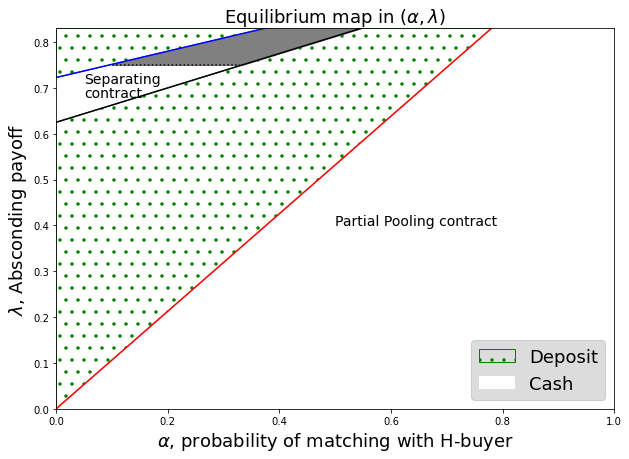

In [88]:
([sigma_c, uH_c, q_c, theta_c, u_c, tcL_c, tcH_c])= ([0.4, 12, 0.15, 6, 4.5, 0.03, 0.03])
#([0.4, 12, 0.15, 6, 4.5, 0.03, 0.03]): optimal so far

#([0.4, 12, 0.25, 3.5, 8, 0.03, 0.03]): original
plt.figure(figsize=(10, 7))
x = np.linspace(0,1,num=100)
y = np.linspace(0, 1,num=100)
z=np.linspace(0.10, 0.33, num=100)
#lam_1: for x > lam_1 => B_Sep > B_PP 
lam_1_s = lambdify(['alpha'], lam_1.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
#lam_2: for x < lam_2 => S_Sep > S_Dep
lam_2_s = lambdify(['alpha'], lam_2.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
#lam_3: for x < lam_3 => S_PP > S_Dep
lam_3_s = lambdify(['alpha'], lam_3.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))    
#Participation constraint for the bank at offer Seperating contract
lam_7_2 = lam_7[1].subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)])
lam_7_s= lam_7_2* np.ones_like(x)  # Constant value 3 for the range
#Participation constraint for the bank to offer Deposit
lam_9_2 = lam_9[1].subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)])
lam_9_s = lam_9_2*np.ones_like(x)
#Participation constraint for the bank to offer Partial pooling constraint
lam_8_s = lambdify(['alpha'], lam_8[1].subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))

#Constraint on q to eliminate Partial Participation constract
q_bar = pL/(pH)
q_bar = lambdify(['lambda_'], q_bar.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))

lam_7_f=float(lam_7_2)
lam_7_f = lam_7_f*np.ones_like(x)
plt.plot(z, lam_7_s, 'k:')
#plt.plot(x, lam_8_s(x), 'r:')
plt.plot(x, lam_9_s, 'y:')
plt.plot(x, lam_1_s(x), 'k')
plt.plot(x, lam_2_s(x), 'b')
plt.plot(y, lam_3_s(y), 'r')

plt.fill_between(x, lam_2_s(x), 0.83,facecolor="none", edgecolor="green", hatch='.')
plt.fill_between(x, lam_1_s(x), lam_3_s(x),facecolor="none", edgecolor="green", hatch='.', label="Deposit")
plt.fill_between(x, lam_3_s(x), 0,facecolor="white", label="Cash")
lim1 = np.maximum(lam_7_f, lam_1_s(x))
plt.fill_between(x, lim1, lam_2_s(x), where=(x>=0.1) ,facecolor="grey", edgecolor="grey")
#print(type(lam_1_s))

plt.text(.05, .71, "Separating", fontsize=14)
plt.text(.05, .68, "contract", fontsize=14)
plt.text(.5, .4, "Partial Pooling contract", fontsize=14)

plt.xlabel( r"$\alpha$, probability of matching with H-buyer ",fontsize=18)
plt.ylabel(r'$\lambda$, Absconding payoff', fontsize=18)
plt.title(r'Equilibrium map in $(\alpha, \lambda)$', fontsize=18)
plt.axis([0, 1, 0, 0.83])
plt.legend(loc='lower right', fontsize = 18, facecolor = "gainsboro", framealpha=1, markerscale=50)

print("pH is ", pH.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
print("pL is ", pL.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
print("ph is ", ph.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
print("rH_Sep is ", rH_S.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
print("The following assumptions are necessary")
print("1) pH > pL") 
ass_1 = (1 - lambda_)*theta*q
print("2) The following needs to be less than 1: ", ass_1.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
ass_2 = (1 - lambda_)*theta
print(Fore.RED + "3) The following needs to be greater than 1: ", ass_2.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]),)

print("The above value meets the requirement with the current chosen parameter values WHEN lambda < 0.8 ")
print(Style.RESET_ALL)
print("5. q < pL/(pH): Partial Participation contract is dominated by Partial Pooling contract to the lending bank")

print("$q$ needs to be lower than the min of ", round(q_bar(0.1),2), " and ", round(q_bar(0.8),2))

print("The bank's threshold for Separating contract", lam_7_2)
print("The bank's payoff for separating contract with these parameters and lambda at 0.2 is ", B_Sep.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (lambda_, 0.2)]))
print("The bank's threshold for Deposit contract is ", lam_9_2)

#### Payoff of the lending bank 

=> do NOT need to care about the lambda boundary for the current parameters

#### Payoff of the sellers (INCOMPLETE)

In [23]:
S_St

q*(-(1 - lambda)*(1 - tcL)*(lambda*sigma + u*(1 - sigma)) + (1 - tcH)*(lambda*sigma - sigma*(theta - 1) + uH*(1 - sigma))) + (1 - q)*(-(1 - lambda)*(1 - tcL)*(lambda*sigma + u*(1 - sigma)) + (1 - tcL)*(lambda*sigma + u*(1 - sigma)))

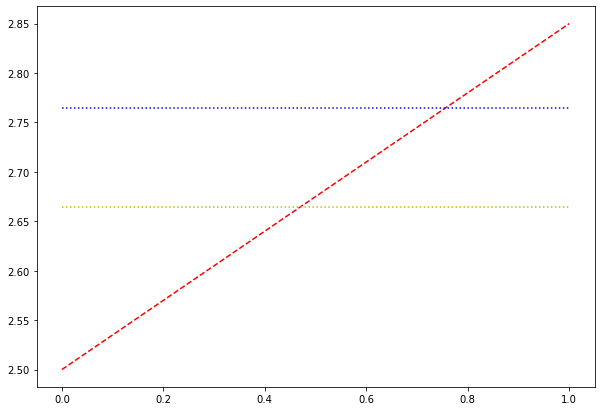

In [27]:
([sigma_c, uH_c, q_c, theta_c, u_c, tcL_c, tcH_c])= ([0.4, 12, 0.25, 3.5, 8, 0.03, 0.03])
plt.figure(figsize=(10, 7))
x = np.linspace(0,1,num=100)
S_St_s = S_St.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c), (lambda_, 0.5)])
#plt.plot(x, S_St_s, '--y')
#NO SEPRATING CONTRACT FOR LOW LAMBDA
#S_Sep_s = lambdify(['alpha'],S_Sep.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c), (lambda_, 0.2)]))
#plt.plot(x, S_Sep_s(x), '--r')
S_PP_s = lambdify(['alpha'],S_PP.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c), (lambda_, 0.5)]))
plt.plot(x, S_PP_s(x), '--r')
S_Dep_s = S_Dep.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c), (lambda_, 0.5)])
#plt.plot(x, S_Dep_s(x), '--k')
S_Dep_s= S_Dep_s* np.ones_like(x)  # Constant value 3 for the range
plt.plot(x, S_Dep_s, 'y:')
S_St_s= S_St_s* np.ones_like(x)  # Constant value 3 for the range
plt.plot(x, S_St_s, 'b:')

#print(S_St_s)
#print(S_Dep_s)

#### Look at the comparison between stablecoins method and others

Compare stablecoins with cash in partial pooling contract

In [58]:
Dif_St_PP_1 = S_St - S_PP
Dif_St_PP = factor(Dif_St_PP_1, lambda_)
print(Dif_St_PP)
Dif_St_PP

alpha*q*sigma*theta - alpha*q*sigma*u + alpha*q*sigma*uH - alpha*q*sigma + alpha*q*u - alpha*q*uH - lambda**2*sigma*tcL - lambda*(q*sigma*tcH - q*sigma*tcL - sigma*tcL*u + tcL*u) + q*sigma*tcH*theta + q*sigma*tcH*uH - q*sigma*tcH - q*sigma*tcL*u - q*sigma*theta + q*sigma*u - q*sigma*uH + q*sigma - q*tcH*uH + q*tcL*u - q*u + q*uH


alpha*q*sigma*theta - alpha*q*sigma*u + alpha*q*sigma*uH - alpha*q*sigma + alpha*q*u - alpha*q*uH - lambda**2*sigma*tcL - lambda*(q*sigma*tcH - q*sigma*tcL - sigma*tcL*u + tcL*u) + q*sigma*tcH*theta + q*sigma*tcH*uH - q*sigma*tcH - q*sigma*tcL*u - q*sigma*theta + q*sigma*u - q*sigma*uH + q*sigma - q*tcH*uH + q*tcL*u - q*u + q*uH

Solve for lambda between STABLECOIN and PARTIAL POOLING cash. Since the coefficient of $\lambda^2$ is negative, the area where stablecoin yield higher payoff than PP cash is between the two lambda roots

In [59]:
lam_ST_PP = solve(Dif_St_PP, lambda_)
#print((lam_ST_PP)[0])
lam_4_1 = lam_ST_PP[0]
lam_4_2 = lam_ST_PP[1]
#print(lam_4_2)
lam_4_1

(-q*sigma*tcH + q*sigma*tcL + sigma*tcL*u - tcL*u - sqrt(4*alpha*q*sigma**2*tcL*theta - 4*alpha*q*sigma**2*tcL*u + 4*alpha*q*sigma**2*tcL*uH - 4*alpha*q*sigma**2*tcL + 4*alpha*q*sigma*tcL*u - 4*alpha*q*sigma*tcL*uH + q**2*sigma**2*tcH**2 - 2*q**2*sigma**2*tcH*tcL + q**2*sigma**2*tcL**2 + 4*q*sigma**2*tcH*tcL*theta - 2*q*sigma**2*tcH*tcL*u + 4*q*sigma**2*tcH*tcL*uH - 4*q*sigma**2*tcH*tcL - 2*q*sigma**2*tcL**2*u - 4*q*sigma**2*tcL*theta + 4*q*sigma**2*tcL*u - 4*q*sigma**2*tcL*uH + 4*q*sigma**2*tcL + 2*q*sigma*tcH*tcL*u - 4*q*sigma*tcH*tcL*uH + 2*q*sigma*tcL**2*u - 4*q*sigma*tcL*u + 4*q*sigma*tcL*uH + sigma**2*tcL**2*u**2 - 2*sigma*tcL**2*u**2 + tcL**2*u**2))/(2*sigma*tcL)

Checking the two roots with the given parmeter values

In [60]:

lam_4_1_t = lam_4_1.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c)])
lam_4_1_t

-6.45779567654475*sqrt(1 - 0.749344323716748*alpha) - 3.375

In [61]:
lam_4_2_t = lam_4_2.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c)])
lam_4_2_t

6.45779567654475*sqrt(1 - 0.749344323716748*alpha) - 3.375

The area where STABLECOIN yields higher payoff than PARTIAL POOLING is lower than the line of lam_4_2 (and higher than lam_4_1)

(0.0, 1.0, 0.0, 0.8)

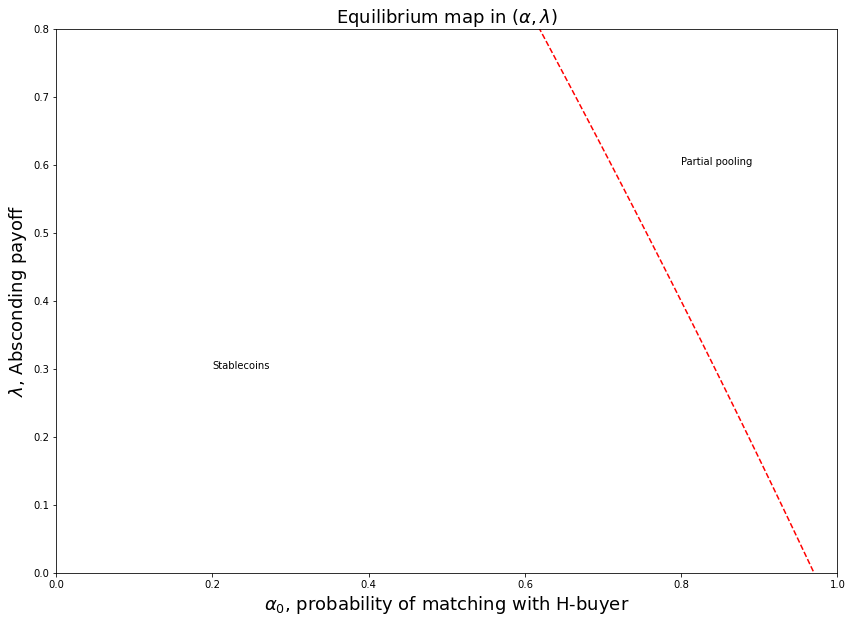

In [15]:
#([sigma_c, uH_c, q_c, theta_c, u_c, tcL_c, tcH_c])= ([0.4, 12, 0.2, 4, 8, 0.05, 0.05])
plt.figure(figsize=(14, 10))
x = np.linspace(0,1,num=100)
lam_4_s = lambdify(['alpha'],lam_4_2.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c)]))
plt.plot(x, lam_4_s(x), '--r')
plt.text(.2, .3, "Stablecoins")
plt.text(.8, .6, "Partial pooling")
plt.xlabel( r"$\alpha_0$, probability of matching with H-buyer ",fontsize=18)
plt.ylabel(r'$\lambda$, Absconding payoff', fontsize=18)
plt.title(r'Equilibrium map in $(\alpha, \lambda)$', fontsize=18)
plt.axis([0, 1, 0, 0.8])

Compare the payoffs of sellers using STABLECOIN and BANKING DEPOSIT 

In [62]:
Dif_St_Dep_1 = S_St - S_Dep
Dif_St_Dep = factor(Dif_St_Dep_1, lambda_)
print(Dif_St_Dep)
Dif_St_Dep

-1.0*(1.0*lambda**2*sigma*tcL + lambda*(1.0*q*sigma*tcH - 1.0*q*sigma*tcL - 1.0*q*sigma*theta + 1.0*q*sigma*u - 1.0*q*sigma*uH + 1.0*q*sigma - 0.025*q*theta - 1.0*q*u + 1.0*q*uH - 1.0*sigma*tcL*u + 1.0*tcL*u) - 1.0*q*sigma*tcH*theta - 1.0*q*sigma*tcH*uH + 1.0*q*sigma*tcH + 1.0*q*sigma*tcL*u + 1.0*q*sigma*theta - 1.0*q*sigma*u + 1.0*q*sigma*uH - 1.0*q*sigma + 1.0*q*tcH*uH - 1.0*q*tcL*u + 1.0*q*u - 1.0*q*uH)


-1.0*(1.0*lambda**2*sigma*tcL + lambda*(1.0*q*sigma*tcH - 1.0*q*sigma*tcL - 1.0*q*sigma*theta + 1.0*q*sigma*u - 1.0*q*sigma*uH + 1.0*q*sigma - 0.025*q*theta - 1.0*q*u + 1.0*q*uH - 1.0*sigma*tcL*u + 1.0*tcL*u) - 1.0*q*sigma*tcH*theta - 1.0*q*sigma*tcH*uH + 1.0*q*sigma*tcH + 1.0*q*sigma*tcL*u + 1.0*q*sigma*theta - 1.0*q*sigma*u + 1.0*q*sigma*uH - 1.0*q*sigma + 1.0*q*tcH*uH - 1.0*q*tcL*u + 1.0*q*u - 1.0*q*uH)

Checking the two roots 

In [63]:
lam_ST_Dep = solve(Dif_St_Dep, lambda_)
#print((lam_ST_PP)[0])
lam_5_1 = lam_ST_Dep[0]
lam_5_2 = lam_ST_Dep[1]
lam_5_1_t = lam_5_1.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c)])
lam_5_2_t = lam_5_2.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c)])
print(lam_5_2_t)
print(lam_5_1_t)

0.820466034233056
-36.9454660342331


The area where STABLECOIN yields higher payoff than DEPOSIT is between the two values above, 0.4 and -23.48

Compare the payoffs of seller using STABLECOIN and SEPARATING contract cash

In [64]:
Dif_St_Sep = S_St - S_Sep
Dif_St_Sep = factor(Dif_St_Sep, lambda_)
print(Dif_St_Sep)
Dif_St_Sep

-alpha*q*sigma*u + alpha*q*sigma*uH + alpha*q*u - alpha*q*uH - lambda**2*sigma*tcL - lambda*(q*sigma*tcH - q*sigma*tcL - sigma*tcL*u - sigma*theta + sigma + tcL*u) + q*sigma*tcH*theta + q*sigma*tcH*uH - q*sigma*tcH - q*sigma*tcL*u + q*sigma*u - q*sigma*uH - q*tcH*uH + q*tcL*u - q*u + q*uH - sigma*theta + sigma


-alpha*q*sigma*u + alpha*q*sigma*uH + alpha*q*u - alpha*q*uH - lambda**2*sigma*tcL - lambda*(q*sigma*tcH - q*sigma*tcL - sigma*tcL*u - sigma*theta + sigma + tcL*u) + q*sigma*tcH*theta + q*sigma*tcH*uH - q*sigma*tcH - q*sigma*tcL*u + q*sigma*u - q*sigma*uH - q*tcH*uH + q*tcL*u - q*u + q*uH - sigma*theta + sigma

In [65]:
([sigma_c, uH_c, q_c, theta_c, u_c, tcL_c, tcH_c])= ([0.4, 12, 0.25, 3.5, 8, 0.03, 0.03])

Dif_St_Sep_gr = Dif_St_Sep.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c), (alpha, 0.4)])
Dif_St_Sep_gr

-0.012*lambda**2 + 0.856*lambda - 0.6505

In [66]:
([sigma_c, uH_c, q_c, theta_c, u_c, tcL_c, tcH_c])= ([0.4, 12, 0.25, 3.5, 8, 0.03, 0.03])
lam_ST_Sep = solve(Dif_St_Sep, lambda_)
#print((lam_ST_PP)[0])
lam_6_1 = lam_ST_Sep[0]
lam_6_2 = lam_ST_Sep[1]
lam_6_1_t = lam_6_1.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c)])
lam_6_2_t = lam_6_2.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c)])
print(lam_6_1)
print(lam_6_2_t)
lam_6_1_t

(-q*sigma*tcH + q*sigma*tcL + sigma*tcL*u + sigma*theta - sigma - tcL*u - sqrt(-4*alpha*q*sigma**2*tcL*u + 4*alpha*q*sigma**2*tcL*uH + 4*alpha*q*sigma*tcL*u - 4*alpha*q*sigma*tcL*uH + q**2*sigma**2*tcH**2 - 2*q**2*sigma**2*tcH*tcL + q**2*sigma**2*tcL**2 + 4*q*sigma**2*tcH*tcL*theta - 2*q*sigma**2*tcH*tcL*u + 4*q*sigma**2*tcH*tcL*uH - 4*q*sigma**2*tcH*tcL - 2*q*sigma**2*tcH*theta + 2*q*sigma**2*tcH - 2*q*sigma**2*tcL**2*u + 2*q*sigma**2*tcL*theta + 4*q*sigma**2*tcL*u - 4*q*sigma**2*tcL*uH - 2*q*sigma**2*tcL + 2*q*sigma*tcH*tcL*u - 4*q*sigma*tcH*tcL*uH + 2*q*sigma*tcL**2*u - 4*q*sigma*tcL*u + 4*q*sigma*tcL*uH + sigma**2*tcL**2*u**2 + 2*sigma**2*tcL*theta*u - 4*sigma**2*tcL*theta - 2*sigma**2*tcL*u + 4*sigma**2*tcL + sigma**2*theta**2 - 2*sigma**2*theta + sigma**2 - 2*sigma*tcL**2*u**2 - 2*sigma*tcL*theta*u + 2*sigma*tcL*u + tcL**2*u**2))/(2*sigma*tcL)
35.1838425669764*sqrt(1 - 0.0403908940973196*alpha) + 35.6666666666667


35.6666666666667 - 35.1838425669764*sqrt(1 - 0.0403908940973196*alpha)

#### => The area where STABLECOIN yield higher payoff than SEPARATING CASH contract is between the two roots, meaning higher than lam_6_1

(0.0, 1.0, 0.0, 0.8)

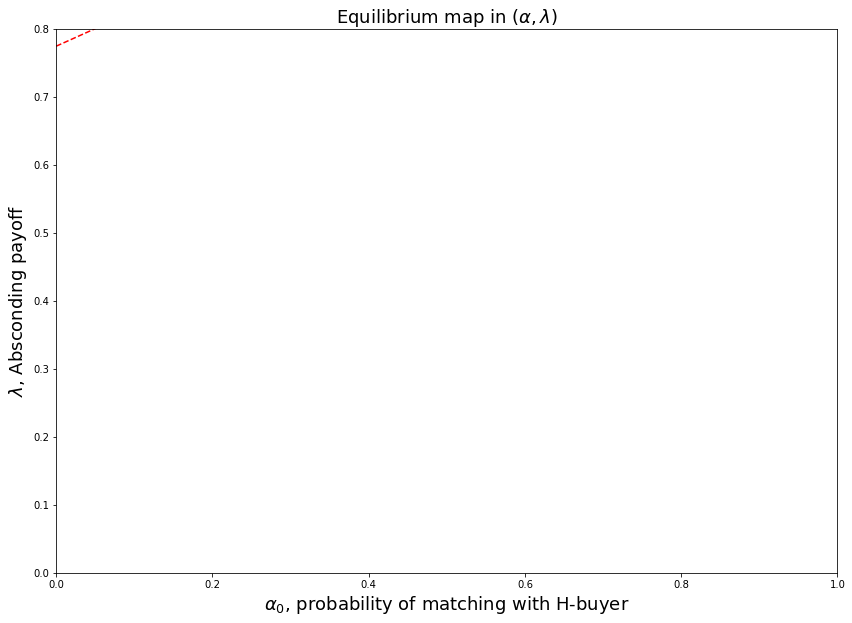

In [36]:
([sigma_c, uH_c, q_c, theta_c, u_c, tcL_c, tcH_c])= ([0.4, 12, 0.2, 4, 8, 0.05, 0.05])
plt.figure(figsize=(14, 10))
x = np.linspace(0,1,num=100)
lam_6_s = lambdify(['alpha'],lam_6_1.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c)]))
plt.plot(x, lam_6_s(x), '--r')
plt.xlabel( r"$\alpha_0$, probability of matching with H-buyer ",fontsize=18)
plt.ylabel(r'$\lambda$, Absconding payoff', fontsize=18)
plt.title(r'Equilibrium map in $(\alpha, \lambda)$', fontsize=18)
plt.axis([0, 1, 0, 0.8])

#### Graph with stablecoin compare to cash and deposit, and $u > \theta$

pH is  0.4*lambda + 5.2
pL is  0.4*lambda + 2.7
ph is  0.4*lambda + 0.699999999999999
rH_Sep is  6*lambda + (1 - lambda)*(0.4*lambda + 0.699999999999999)
The following assumptions are necessary
1) pH > pL
2) The following needs to be less than 1:  0.9 - 0.9*lambda
3) The following needs to be greater than 1:  6 - 6*lambda
The above value meets the requirement with the current chosen parameter values WHEN lambda < 0.7 

5. q < pL/(pH): Partial Participation contract is dominated by Partial Pooling contract to the lending bank
$q$ needs to be lower than the min of  0.52  and  0.55
0.750000000000002
The bank's payoff for separating contract with these parameters and lambda at 0.2 is  0.374000000000000
The Lambda threshold for the bank to offer Stablecoin contract is  0.92


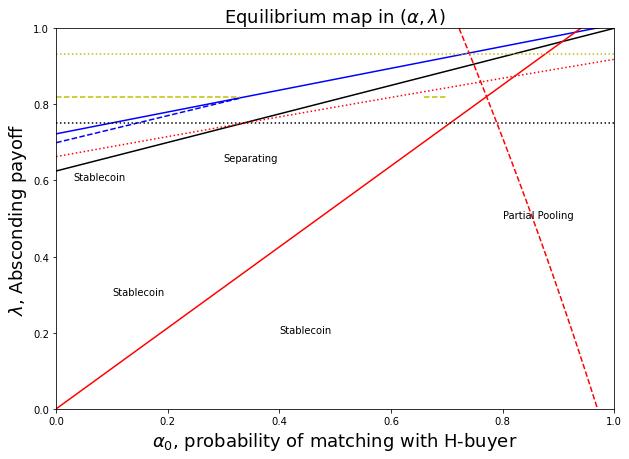

In [93]:

#Original parameter values:([sigma_c, uH_c, q_c, theta_c, u_c, tcL_c, tcH_c])= ([0.4, 12, 0.25, 3.5, 8, 0.03, 0.03])

([sigma_c, uH_c, q_c, theta_c, u_c, tcL_c, tcH_c])= ([0.4, 12, 0.15, 6, 4.5, 0.03, 0.03])
plt.figure(figsize=(10, 7))
x = np.linspace(0,1,num=100)
y = np.linspace(0, .33,num=100)
z = np.linspace(0.65, 1, num=100)
t = np.linspace(.66, .7, num=100)
v = np.linspace(0.29, 0.56, num=100)
#lam_1: for x > lam_1 => B_Sep > B_PP 
lam_1_s = lambdify(['alpha'], lam_1.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
#lam_2: for x < lam_2 => S_Sep > S_Dep 
lam_2_s = lambdify(['alpha'], lam_2.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
#lam_3: for x < lam_3 => S_PP > S_Dep 
lam_3_s = lambdify(['alpha'], lam_3.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))    
plt.plot(x, lam_1_s(x), 'k')
plt.plot(x, lam_2_s(x), 'b')
plt.plot(x, lam_3_s(x), 'r')

#lam_4: for x < lam_4_2 => S_STA > S_PP 
lam_4_s = lambdify(['alpha', 'tcL', 'tcH'],lam_4_2.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
plt.plot(z, lam_4_s(z, 0.03, 0.03), '--r')
"""lam_6: for x > lam_6_1 => S_STA > S_Sep"""
lam_6_s = lambdify(['alpha'],lam_6_1.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c)]))
plt.plot(y, lam_6_s(y), '--b')
#lam_5: for x < lam_5_2 => S_STA > S_Dep 
lam_5_2_t = lam_5_2.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c)])
lam_5_s = lam_5_2_t * np.ones_like(y)  # Constant value 3 for the range
plt.plot(y, lam_5_s, '--y')
plt.plot(t, lam_5_s, '--y')

#Constraint on q to eliminate Partial Participation constract
q_bar = pL/(pH)
q_bar = lambdify(['lambda_'], q_bar.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))

#Participation constraint for the bank at offer Seperating contract
lam_7_2 = lam_7[1].subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)])
lam_7_s= lam_7_2* np.ones_like(x)  # Constant value 3 for the range
#Participation constraint for the bank to offer Deposit
lam_9_2 = lam_9[1].subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)])
lam_9_s = lam_9_2*np.ones_like(x)
#Participation constraint for the bank to offer Partial pooling constraint
lam_8_s = lambdify(['alpha'], lam_8[1].subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
#Participation constraint for the bank to offer Stablecoin constraint
lam_10_s = lam_10[0].subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c)])
"""The following line is comment out if it return complex number and hence cannot be drawn"""
plt.plot(x, lam_7_s, 'k:')
plt.plot(x, lam_8_s(x), 'r:')
plt.plot(x, lam_9_s, 'y:')




plt.text(.03, .6, "Stablecoin")
plt.text(.8, .5, "Partial Pooling")
plt.text(.4, .2, "Stablecoin")
plt.text(.1, .3, "Stablecoin")
plt.text(.3, .65, "Separating")

plt.xlabel( r"$\alpha_0$, probability of matching with H-buyer ",fontsize=18)
plt.ylabel(r'$\lambda$, Absconding payoff', fontsize=18)
plt.title(r'Equilibrium map in $(\alpha, \lambda)$', fontsize=18)
plt.axis([0, 1, 0, 1])
print("pH is ", pH.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
print("pL is ", pL.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
print("ph is ", ph.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
print("rH_Sep is ", rH_S.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
print("The following assumptions are necessary")
print("1) pH > pL") 
ass_1 = (1 - lambda_)*theta*q
print("2) The following needs to be less than 1: ", ass_1.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
ass_2 = (1 - lambda_)*theta
print(Fore.RED + "3) The following needs to be greater than 1: ", ass_2.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]),)

print("The above value meets the requirement with the current chosen parameter values WHEN lambda < 0.7 ")
print(Style.RESET_ALL)
print("5. q < pL/(pH): Partial Participation contract is dominated by Partial Pooling contract to the lending bank")

print("$q$ needs to be lower than the min of ", round(q_bar(0.1),2), " and ", round(q_bar(0.8),2))

print(lam_7_2)
print("The bank's payoff for separating contract with these parameters and lambda at 0.2 is ", B_Sep.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (lambda_, 0.2)]))
print("The Lambda threshold for the bank to offer Stablecoin contract is ", round(lam_10_s,2))

### Mirroring Toni's paper, where $u < \theta$

pH is  0.4*lambda + 2.0
pL is  0.4*lambda + 1.5
ph is  0.4*lambda - 0.1
rH_Sep is  5*lambda + (1 - lambda)*(0.4*lambda - 0.1)
The following assumptions are necessary
1) pH > pL. 2) pL > theta
3) The following needs to be less than 1:  0.55 - 0.55*lambda
4) The following needs to be greater than 1:  5 - 5*lambda
The above value meets the requirement with the current chosen parameter values WHEN lambda < 0.8 

5. q < ph/(pH*alpha)
[(sigma*theta + sigma*u - u - sqrt(4*q*sigma*theta - 4*q*sigma + sigma**2*theta**2 + 2*sigma**2*theta*u - 4*sigma**2*theta + sigma**2*u**2 - 4*sigma**2*u + 4*sigma**2 - 2*sigma*theta*u - 2*sigma*u**2 + 4*sigma*u - 4*sigma + u**2))/(2*sigma), (sigma*theta + sigma*u - u + sqrt(4*q*sigma*theta - 4*q*sigma + sigma**2*theta**2 + 2*sigma**2*theta*u - 4*sigma**2*theta + sigma**2*u**2 - 4*sigma**2*u + 4*sigma**2 - 2*sigma*theta*u - 2*sigma*u**2 + 4*sigma*u - 4*sigma + u**2))/(2*sigma)]
0.625 + 1.12221878437317*I
The bank's payoff for separating contract with these para

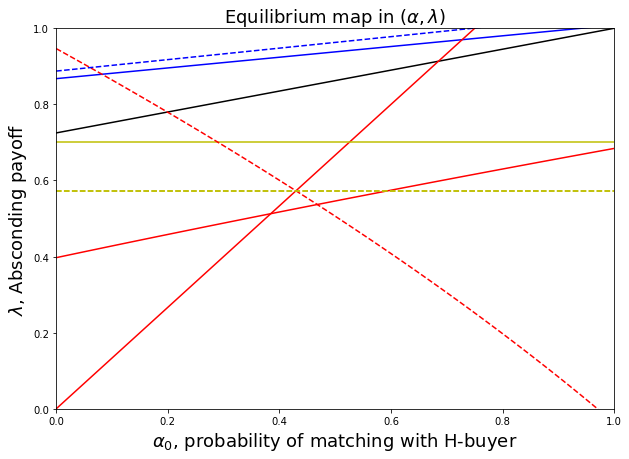

In [47]:
from colorama import Fore, Back, Style

([sigma_c, uH_c, q_c, theta_c, u_c, tcL_c, tcH_c])= ([0.4, 6, 0.11, 5, 2.5, 0.03, 0.03])
plt.figure(figsize=(10, 7))
x = np.linspace(0,1,num=100)
y = np.linspace(0, .56,num=100)
z = np.linspace(0.73, 1, num=100)
t = np.linspace(.68, .73, num=100)
v = np.linspace(0.29, 0.56, num=100)
#lam_1: for x < lam_1 => B_Sep < B_PP 
lam_1_s = lambdify(['alpha'], lam_1.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
#lam_2: for x < lam_2 => S_Sep > S_Dep 
lam_2_s = lambdify(['alpha'], lam_2.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
#lam_3: for x < lam_3 => S_PP > S_Dep
lam_3_s = lambdify(['alpha'], lam_3.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))    
plt.plot(x, lam_1_s(x), 'k')
plt.plot(x, lam_2_s(x), 'b')
plt.plot(x, lam_3_s(x), 'r')

#Participation constraint for the bank at offer Seperating contract
lam_7_2 = lam_7[1].subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)])
lam_7_s= lam_7_2* np.ones_like(x)  # Constant value 3 for the range
#Participation constraint for the bank to offer Deposit
lam_9_2 = lam_9[1].subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)])
lam_9_s = lam_9_2*np.ones_like(x)
#Participation constraint for the bank to offer Partial pooling constraint
lam_8_s = lambdify(['alpha'], lam_8[1].subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
#Participation constraint for the bank to offer Stablecoin constraint
lam_10_s = lam_10[0].subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c)])

"""The following line is comment out if it return complex number and hence cannot be drawn"""
#plt.plot(x, lam_7_s, 'k')
plt.plot(x, lam_8_s(x), 'r')
plt.plot(x, lam_9_s, 'y')


lam_4_s = lambdify(['alpha'],lam_4_2.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c)]))
#plt.plot(z, lam_4_s(z), '--r')
plt.plot(x, lam_4_s(x), '--r')
lam_6_s = lambdify(['alpha'],lam_6_1.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c)]))
#plt.plot(v, lam_6_s(v), '--b')
plt.plot(x, lam_6_s(x), '--b')
lam_5_2_t = lam_5_2.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c)])
lam_5_s = lam_5_2_t * np.ones_like(y)  # Constant value 3 for the range
#plt.plot(y, lam_5_s, '--y')
plt.plot(x, lam_5_s, '--y')
#plt.plot(t, lam_5_s, '--y')
plt.plot(x, lam_5_s, '--y')
#plt.text(.03, .6, "Stablecoin")


plt.xlabel( r"$\alpha_0$, probability of matching with H-buyer ",fontsize=18)
plt.ylabel(r'$\lambda$, Absconding payoff', fontsize=18)
plt.title(r'Equilibrium map in $(\alpha, \lambda)$', fontsize=18)
plt.axis([0, 1, 0, 1])
print("pH is ", pH.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
print("pL is ", pL.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
print("ph is ", ph.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
print("rH_Sep is ", rH_S.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
print("The following assumptions are necessary")
print("1) pH > pL. 2) pL > theta")
ass_1 = (1 - lambda_)*theta*q
print("3) The following needs to be less than 1: ", ass_1.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
ass_2 = (1 - lambda_)*theta
print(Fore.RED + "4) The following needs to be greater than 1: ", ass_2.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]),)

print("The above value meets the requirement with the current chosen parameter values WHEN lambda < 0.8 ")
print(Style.RESET_ALL)
print("5. q < ph/(pH*alpha)")
print(lam_7)
print(lam_7_2)
print("The bank's payoff for separating contract with these parameters and lambda at 0.2 is ", B_Sep.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (lambda_, 0.2)]))
print("The Lambda threshold for the bank to offer Stablecoin contract is ", round(lam_10_s,2))

#### Calculate the meeting points of the lines on the graphs, to determine the limits of the linspace used in filling the graph

In [85]:
a_1 = solve(lam_5_2 - lam_2, alpha)
a_1 = a_1[0].subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c)])
a_1 = round(a_1,2)
print(a_1)


0.55


#### Graph with stablecoin compare to cash and deposit, and $q = 0.4$

pH is  0.4*lambda + 5.2
pL is  0.4*lambda + 2.7
ph is  0.4*lambda + 0.699999999999999
pLst is  0.388*lambda + 2.619
rH_Sep is  6*lambda + (1 - lambda)*(0.4*lambda + 0.699999999999999)
The following needs to be less than 1:  0.9 - 0.9*lambda . Could impose lambda >0.2. Not too far from reality since bank need to at least give seller some money I suppose (?)
The following needs to be greater than 1:  6 - 6*lambda
The above value does not meet the requirement with the current chosen parameter values. NEED to set lambda < 0.75 

5. q < pL/(pH): Partial Participation contract is dominated by Partial Pooling contract to the lending bank
$q$ needs to be lower than the min of  0.52  and  0.55
The bank's threshold for Separating contract 0.750000000000002
The bank's payoff for separating contract with these parameters and lambda at 0.2 is  0.374000000000000
The bank's threshold for Deposit contract is  0.933594827288887
The Lambda threshold for the bank to offer Stablecoin contract is  0.92


<Figure size 720x504 with 0 Axes>

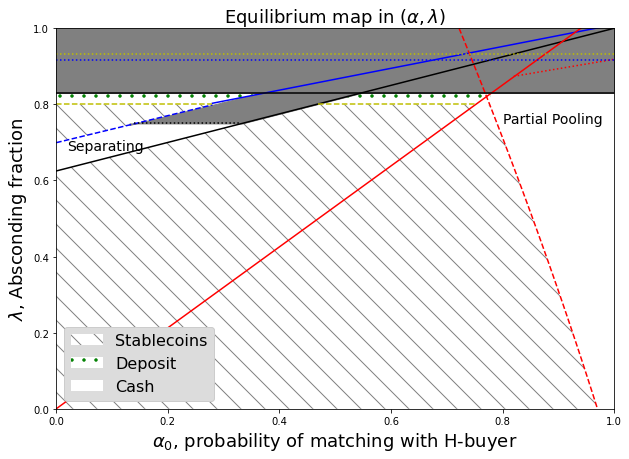

In [129]:
from colorama import Fore, Back, Style
([sigma_c, uH_c, q_c, theta_c, u_c, tcL_c, tcH_c])= ([0.4, 12, 0.15, 6, 4.5, 0.03, 0.03])


plt.figure(figsize=(10, 7))
x = np.linspace(0,1,num=100)
y = np.linspace(0, .28,num=100)
z = np.linspace(0.65, 1, num=100)
t = np.linspace(.47, .75, num=100)
v = np.linspace(0.29, 0.56, num=100)
vv = np.linspace(0.33,1, num=100)
tt = np.linspace(.29, .68, num=100)
x1=np.linspace(0.82, 1, num=100)
x2 = np.linspace(0.28, 1, num=100)
x3=np.linspace(.14, .33, num=100)
fig_1 = plt.figure(figsize=(10, 7))

lam_1_s = lambdify(['alpha'], lam_1.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
lam_2_s = lambdify(['alpha'], lam_2.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
lam_3_s = lambdify(['alpha'], lam_3.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))    
plt.plot(x, lam_1_s(x), 'k')
plt.plot(x2, lam_2_s(x2), 'b')
plt.plot(x, lam_3_s(x), 'r')
#lam_4_s = lambdify(['alpha'],lam_4_2.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c)]))
#plt.plot(z, lam_4_s(z), '--r')
#lam_6_s = lambdify(['alpha'],lam_6_1.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c)]))
#plt.plot(y, lam_6_s(y), '--b')
#lam_5_2_t = lam_5_2.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c)])
#lam_5_s = lam_5_2_t * np.ones_like(y)  # Constant value 3 for the range
#Dep = float(lam_5_2_t)
#Dep = Dep* np.ones_like(y)
#plt.plot(y, lam_5_s, '--y')
#plt.plot(t, lam_5_s, '--y')


#lam_4: for x < lam_4_2 => S_STA > S_PP 
lam_4_s = lambdify(['alpha', 'tcL', 'tcH'],lam_4_2.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
plt.plot(z, lam_4_s(z, 0.03, 0.03), '--r')
"""lam_6: for x > lam_6_1 => S_STA > S_Sep"""
lam_6_s = lambdify(['alpha'],lam_6_1.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c)]))
plt.plot(y, lam_6_s(y), '--b')
#lam_5: for x < lam_5_2 => S_STA > S_Dep 
lam_5_2_t = lam_5_2.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c)])
lam_5_s = (lam_5_2_t-0.02) * np.ones_like(y)  # Constant value 3 for the range
plt.plot(y, lam_5_s, '--y')
plt.plot(t, lam_5_s, '--y')
Dep = float(lam_5_2_t)
Dep = (Dep-0.02)* np.ones_like(x)
#Lambda that meet Assumption 1 (ass_2) for the parameter values in this cell
Lass1 = (0.83)*np.ones_like(x)
#Constraint on q to eliminate Partial Participation constract
q_bar = pL/(pH)
q_bar = lambdify(['lambda_'], q_bar.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))

#Participation constraint for the bank at offer Seperating contract
lam_7_2 = lam_7[1].subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)])
lam_7_s= lam_7_2* np.ones_like(x)  # Constant value 3 for the range
#Participation constraint for the bank to offer Deposit
lam_9_2 = lam_9[1].subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)])
lam_9_s = lam_9_2*np.ones_like(x)
#Participation constraint for the bank to offer Partial pooling constraint
lam_8_s = lambdify(['alpha'], lam_8[1].subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
#Participation constraint for the bank to offer Stablecoin constraint
lam_10_s = lam_10[0].subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c)])
lam_10_s = lam_10_s*np.ones_like(x)
"""The following line is comment out if it return complex number and hence cannot be drawn"""
plt.plot(x3, lam_7_s, 'k:')
plt.plot(x1, lam_8_s(x1), 'r:')
plt.plot(x, lam_9_s, 'y:')
plt.plot(x, Lass1, 'k')
plt.plot(x, lam_10_s, 'b:')

########-------------FIILING THE GRAPH --------##############
Lam1_Lass1 = np.minimum(lam_1_s(x), Lass1)
St_Sep= np.maximum(lam_1_s(x), lam_6_s(x))#the line above which STABLECOINS is optimal, given the constract being Separating
St_Dep = np.minimum(lam_1_s(x), Dep)# the line below which STABLECOIN is better than Deposit
St_Dep_PP = np.minimum(St_Dep, lam_4_s(x, 0.03, 0.03)) # the line below which STABLECOIN is better than Deposit and PP
#St_Op = np.concatenate([])

Dep_PP = np.maximum(Dep, lam_3_s(x)) #the line above which DEP is better than PP cash
Dep_Sep = np.maximum(Dep, lam_2_s(x)) #the line above which DEP is bettern than SEP cash
#FILLING THE GRAPH where STABLECOIN is better than Deposit given Separating contract
plt.fill_between(x, Dep, lam_6_s(x), where=(x <= 0.35), facecolor="none", edgecolor="grey", lw=0, hatch='\\')
##FILLING THE GRAPH where STABLECOIN is better than CASH given Separating contract
##plt.fill_between(x, St_Sep, lam_2_s(x), where=(x <= 0.55), facecolor="none", edgecolor="gray", lw=0, hatch='\\')
#FILLING THE GRAPH where STABLECOIN is better than Deposit and PP cash
plt.fill_between(x, St_Dep_PP,0, facecolor="white", edgecolor="gray", hatch='\\', lw=0, label="Stablecoins")
#FILLING THE GRAPH where DEP is better than STABLECOIN and SEP cash
plt.fill_between(x, Dep_Sep, Lass1, where=(x<=0.38),facecolor="white", edgecolor="green", lw = 0,hatch='.')
##FILLING THE GRAPH where DEP is better than STABLECOIN and PP cash
plt.fill_between(x,Lam1_Lass1, Dep,where=(x >= 0.45)&(x<=0.78), facecolor="white",edgecolor="green", lw=0, hatch='.', label="Deposit")
#FILLING THE PARTIA POOLING CASH
plt.fill_between(x, lam_4_s(x, 0.03, 0.03), 0.6,where=(x >= 0.85), facecolor="white", label="Cash")

lam_7_f=float(lam_7_2)
lam_7_f = lam_7_f*np.ones_like(x)
lim1 = np.maximum(lam_7_f, lam_1_s(x))
plt.fill_between(x, lim1, lam_6_s(x), where=(x>=0.13) ,facecolor="grey", edgecolor="grey")
plt.fill_between(x, Lass1, 1, facecolor="grey", edgecolor="grey")




plt.text(.8, .75, "Partial Pooling", fontsize =14)
#plt.text(.4, .2, "Stablecoin")
#plt.text(.1, .3, "Stablecoin")
plt.text(.02, .68, "Separating", fontsize =14)

plt.xlabel( r"$\alpha_0$, probability of matching with H-buyer ",fontsize=18)
plt.ylabel(r'$\lambda$, Absconding fraction', fontsize=18)
plt.title(r'Equilibrium map in $(\alpha, \lambda)$', fontsize=18)
plt.axis([0, 1, 0, 1])
plt.legend(loc='lower left', fontsize = 16, facecolor = "gainsboro", framealpha=1, markerscale=40)

print("pH is ", pH.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
print("pL is ", pL.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
print("ph is ", ph.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
pLst = (1 - tcL)*pL
print("pLst is ", pLst.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c)]))

print("rH_Sep is ", rH_S.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
ass_1 = (1 - lambda_)*theta*q
print("The following needs to be less than 1: ", ass_1.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]), ". Could impose lambda >0.2. Not too far from reality since bank need to at least give seller some money I suppose (?)")
ass_2 = (1 - lambda_)*theta
print(Fore.RED + "The following needs to be greater than 1: ", ass_2.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]),)

print("The above value does not meet the requirement with the current chosen parameter values. NEED to set lambda < 0.75 ")
print(Style.RESET_ALL)
print("5. q < pL/(pH): Partial Participation contract is dominated by Partial Pooling contract to the lending bank")

print("$q$ needs to be lower than the min of ", round(q_bar(0.1),2), " and ", round(q_bar(0.8),2))
print("The bank's threshold for Separating contract", lam_7_2)
print("The bank's payoff for separating contract with these parameters and lambda at 0.2 is ", B_Sep.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (lambda_, 0.2)]))
print("The bank's threshold for Deposit contract is ", lam_9_2)
print("The Lambda threshold for the bank to offer Stablecoin contract is ", round(lam_10_s[0],2))

0.5736730214126451
[0.57367302 0.57367302 0.57367302 0.57367302 0.57367302 0.57367302
 0.57367302 0.57367302 0.57367302 0.57367302 0.57367302 0.57367302
 0.57367302 0.57367302 0.57367302 0.57367302 0.57367302 0.57367302
 0.57367302 0.57367302 0.57367302 0.57367302 0.57367302 0.57367302
 0.57367302 0.57367302 0.57367302 0.57367302 0.57367302 0.57367302
 0.57367302 0.57367302 0.57367302 0.57367302 0.57367302 0.57367302
 0.57367302 0.57367302 0.57367302 0.57367302 0.57367302 0.57367302
 0.57367302 0.57367302 0.57367302 0.57367302 0.57367302 0.57367302
 0.57367302 0.57367302 0.57367302 0.57367302 0.57367302 0.57367302
 0.58181818 0.59259259 0.603367   0.61414141 0.62491582 0.63569024
 0.64646465 0.65723906 0.66801347 0.67878788 0.68956229 0.7003367
 0.71111111 0.72188552 0.73265993 0.74343434 0.75420875 0.76498316
 0.77575758 0.78653199 0.7973064  0.80808081 0.81885522 0.82962963
 0.84040404 0.85117845 0.86195286 0.87272727 0.88350168 0.89427609
 0.90505051 0.91582492 0.92659933 0.93737374

<Figure size 720x504 with 0 Axes>

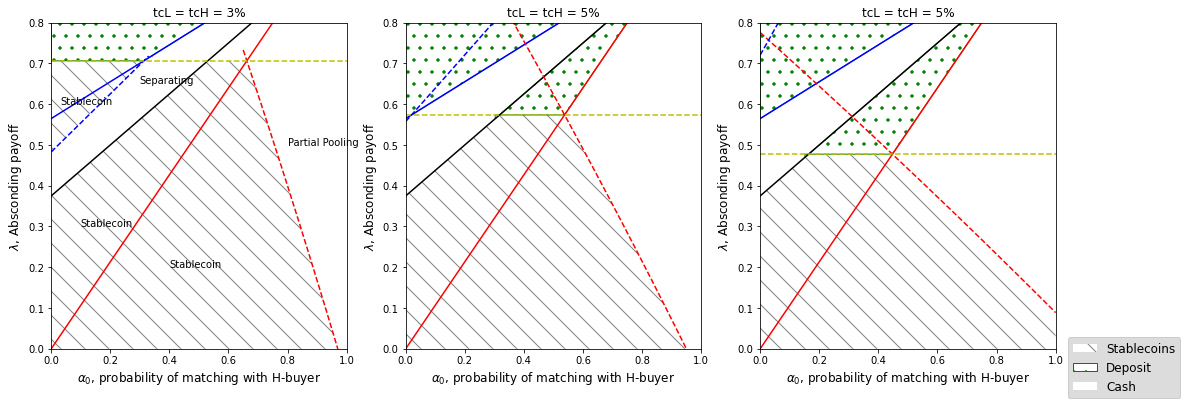

In [70]:
from colorama import Fore, Back, Style
#([sigma_c, uH_c, q_c, theta_c, u_c, tcL_c, tcH_c])= ([0.4, 12, 0.3, 3., 8, 0.03, 0.03])

([sigma_c, uH_c, q_c, theta_c, u_c, tcL_c, tcH_c])= ([0.4, 12, 0.25, 3.5, 8, 0.03, 0.03])
plt.figure(figsize=(10, 7))
x = np.linspace(0,1,num=100)
y = np.linspace(0, .33,num=100)
z = np.linspace(0.65, 1, num=100)
t = np.linspace(.66, .7, num=100)
v = np.linspace(0.29, 0.56, num=100)

# Create a figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot data in each subplot



lam_1_s = lambdify(['alpha'], lam_1.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
lam_2_s = lambdify(['alpha'], lam_2.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
lam_3_s = lambdify(['alpha'], lam_3.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))    

lam_4_s = lambdify(['alpha', 'tcL', 'tcH'],lam_4_2.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
axes[0].plot(z, lam_4_s(z, 0.03, 0.03), '--r')
lam_6_s = lambdify(['alpha', 'tcL', 'tcH'],lam_6_1.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
axes[0].plot(y, lam_6_s(y, 0.03, 0.03), '--b')
lam_5_2_t = lambdify(['tcL', 'tcH'],lam_5_2.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]))
#lam_5_s = lam_5_2_t(0.03, 0.03) * np.ones_like(y)  # Constant value 3 for the range
"""Calculate the points where the red dashed line and the black line meet the yellow dashed line for tcL = tcH = 3%"""
a_4 =  lam_4_2.subs([(tcL, 0.03), (tcH, 0.03), (uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]) 
a_3 = lam_3.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]) 
a_1 = lam_1.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)])
a_5 = lam_5_2.subs([(tcL, 0.03), (tcH, 0.03),(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)])
"""The meeting points for tcL = tcH = 3%"""
#b = round(solve(a_4 - a_3, alpha)[0], 2) 
#a = round(solve(a_1 - a_5, alpha)[0], 2) 
#print(a, b)

"""Calculate the points where the red dashed line and the black line meet the yellow dashed line for tcL = tcH = 5%"""
b_4 =  lam_4_2.subs([(tcL, 0.05), (tcH, 0.05), (uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]) 
b_3 = lam_3.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)]) 
b_1 = lam_1.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)])
b_5 = lam_5_2.subs([(tcL, 0.05), (tcH, 0.05),(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)])
"""The meeting points for tcL = tcH = 5%"""
#d = round(solve(b_4 - b_3, alpha)[0], 2) 
#c = round(solve(b_1 - b_5, alpha)[0], 2) 
#print(c, d)
axes[0].plot(x, lam_1_s(x), 'k')
axes[0].plot(x, lam_2_s(x), 'b')
axes[0].plot(x, lam_3_s(x), 'r')

axes[0].plot(x, lam_5_2_t(0.03, 0.03) * np.ones_like(x), '--y')
axes[0].text(.03, .6, "Stablecoin")
axes[0].text(.8, .5, "Partial Pooling")
axes[0].text(.4, .2, "Stablecoin")
axes[0].text(.1, .3, "Stablecoin")
axes[0].text(.3, .65, "Separating")
axes[0].set_xlabel( r"$\alpha_0$, probability of matching with H-buyer ",fontsize=12)
axes[0].set_ylabel(r'$\lambda$, Absconding payoff', fontsize=12)
axes[0].axis([0, 1, 0, 0.8])

"""-------------FIILING THE GRAPH, tcL = tcH = 3%--------"""
Dep_1 = float(lam_5_2_t(0.03, 0.03))
Dep_1 = Dep_1* np.ones_like(x)
St_Sep= np.maximum(lam_1_s(x), lam_6_s(x, 0.03, 0.03))#the line above which STABLECOINS is optimal, given the constract being Separating
St_Dep_1 = np.minimum(lam_1_s(x), Dep_1)# the line below which STABLECOIN is better than Deposit
St_Dep_PP_1 = np.minimum(St_Dep_1, lam_4_s(x, 0.03, 0.03)) # the line below which STABLECOIN is better than Deposit and PP
#St_Op = np.concatenate([])

Dep_PP = np.maximum(Dep_1, lam_3_s(x)) #the line above which DEP is better than PP cash
Dep_Sep = np.maximum(Dep_1, lam_2_s(x)) #the line above which DEP is bettern than SEP cash


#FILLING THE GRAPH where STABLECOIN is better than Deposit given Separating contract
axes[0].fill_between(x, Dep_1, lam_6_s(x, 0.03, 0.03), where=(x <= 0.35), facecolor="none", edgecolor="gray", lw=0, hatch='\\')
#FILLING THE GRAPH where STABLECOIN is better than Deposit and PP cash
axes[0].fill_between(x, St_Dep_PP_1,0, facecolor="white", edgecolor="gray", hatch='\\', lw=0, label="Stablecoins")
#FILLING THE GRAPH where DEP is better than STABLECOIN and SEP cash
axes[0].fill_between(x, Dep_Sep, 0.8, facecolor="white", edgecolor="green", hatch='.', label="Deposit")
#FILLING THE PARTIA POOLING CASH
axes[0].fill_between(x, lam_4_s(x, 0.03, 0.03), 0.6,where=(x >= 0.75), facecolor="white", label="Cash")

axes[0].set_title('tcL = tcH = 3%')


axes[1].plot(x, lam_1_s(x), 'k')
axes[1].plot(x, lam_2_s(x), 'b')
axes[1].plot(x, lam_3_s(x), 'r')
axes[1].plot(x, lam_4_s(x, 0.05, 0.05), '--r')
axes[1].plot(x, lam_5_2_t(0.05, 0.05) * np.ones_like(x), '--y')
axes[1].plot(x, lam_6_s(x, 0.05, 0.05), '--b')

"""-------------FIILING THE GRAPH, tcL = tcH = 5%--------"""
Dep_2 = float(lam_5_2_t(0.05, 0.05))
Dep_2 = Dep_2* np.ones_like(x)
#St_Sep= np.maximum(lam_1_s(x), lam_6_s(x, 0.05, 0.05))#the line above which STABLECOINS is optimal, given the constract being Separating
St_Dep_2 = np.minimum(lam_1_s(x), Dep_2)# the line below which STABLECOIN is better than Deposit
St_Dep_PP_2 = np.minimum(St_Dep_2, lam_4_s(x, 0.05, 0.05)) # the line below which STABLECOIN is better than Deposit and PP
Dep_PP_St_2 = np.maximum(Dep_2, lam_3_s(x)) #the line above which DEP is better than PP cash


#FILLING THE GRAPH where Deposit is optimal given Separating contract
axes[1].fill_between(x, lam_2_s(x),1,  facecolor="none", edgecolor="green", hatch='.')
#FILLING THE GRAPH where STABLECOIN is better than Deposit and PP cash
axes[1].fill_between(x, St_Dep_PP_2,0, facecolor="white", edgecolor="gray", hatch='\\', lw=0)
ymax_2= float(lam_5_2_t(0.05, 0.05))
#FILLING THE PARTIA POOLING CASH
axes[1].fill_between(x, lam_4_s(x, 0.05, 0.05), 0.6,where=(x >= 0.75), facecolor="white")
#FILLING THE GRAPH where Deposit is optima given Partial Pooling contract
axes[1].fill_between(x, Dep_PP_St_2, lam_1_s(x), where=(x >= 0.3), facecolor="none", edgecolor="green", hatch='.')
print(ymax_2)
axes[1].set_title('tcL = tcH = 5%')

#axes[1].legend()
axes[1].set_xlabel( r"$\alpha_0$, probability of matching with H-buyer ",fontsize=12)
axes[1].set_ylabel(r'$\lambda$, Absconding payoff', fontsize=12)
axes[1].axis([0, 1, 0, 0.8])

#axes[1].grid()

axes[2].plot(x, lam_1_s(x), 'k')
axes[2].plot(x, lam_2_s(x), 'b')
axes[2].plot(x, lam_3_s(x), 'r')
axes[2].plot(x, lam_4_s(x, 0.1, 0.05), '--r')
axes[2].plot(x, lam_5_2_t(0.1, 0.05) * np.ones_like(x), '--y')
axes[2].plot(x, lam_6_s(x, 0.1, 0.05), '--b')

"""-------------FIILING THE GRAPH, tcL = 10%, tcH = 5%--------"""
Dep_3 = float(lam_5_2_t(0.1, 0.05))
Dep_3 = Dep_3* np.ones_like(x)
#St_Sep= np.maximum(lam_1_s(x), lam_6_s(x, 0.05, 0.05))#the line above which STABLECOINS is optimal, given the constract being Separating
St_Dep_3 = np.minimum(lam_1_s(x), Dep_3)# the line below which STABLECOIN is better than Deposit
St_Dep_PP_3 = np.minimum(St_Dep_3, lam_4_s(x, 0.1, 0.05)) # the line below which STABLECOIN is better than Deposit and PP
Dep_PP_St_3 = np.maximum(Dep_3, lam_3_s(x)) #the line above which DEP is better than PP cash


#FILLING THE GRAPH where Deposit is optimal given Separating contract
axes[2].fill_between(x, lam_2_s(x),1,  facecolor="none", edgecolor="green", hatch='.')
#FILLING THE GRAPH where STABLECOIN is better than Deposit and PP cash
axes[2].fill_between(x, St_Dep_PP_3,0, facecolor="white", edgecolor="gray", hatch='\\', lw=0)
ymax_2= float(lam_5_2_t(0.1, 0.05))
#FILLING THE PARTIA POOLING CASH
axes[2].fill_between(x, lam_4_s(x, 0.1, 0.05), 0.6,where=(x >= 0.75), facecolor="white")
#FILLING THE GRAPH where Deposit is optima given Partial Pooling contract
axes[2].fill_between(x, Dep_PP_St_3, lam_1_s(x), where=(x >= 0.15), facecolor="none", edgecolor="green", hatch='.')
print(ymax_2)
axes[2].set_title('tcL = tcH = 5%')


axes[2].set_xlabel( r"$\alpha_0$, probability of matching with H-buyer ",fontsize=12)
axes[2].set_ylabel(r'$\lambda$, Absconding payoff', fontsize=12)
axes[2].axis([0, 1, 0, 0.8])
#fig.suptitle(r'Equilibrium map in $(\alpha, \lambda)$', fontsize=18)
fig.legend(loc='lower right', fontsize = 12, facecolor = "gainsboro", framealpha=1, markerscale=40)
# Show the plot
plt.show()

### Payoff of the sellers when stablecoins are and are not available, $\lambda=0.5$

In [54]:
"""Calculate the point of alpha where the bank switch from separating to partial pooling contract to cash sellers, given lambda_=0.5"""
Alp_Sep_PP = solve(lam_1 - 0.5, alpha)[0]
Alp_Sep_PP = Alp_Sep_PP.subs([(sigma, sigma_c), (q, q_c)])
print(Alp_Sep_PP)
"""Calculate the point of alpha where the seller switches from stablecoin to cash, given the cash contract is separating and lambda_=0.5"""
Alp_St_Sep = solve(lam_6_1 - 0.5, alpha)[0]
Alp_St_Sep = Alp_St_Sep.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c)])
print(Alp_St_Sep)
"""Calculate the point of alpha where the seller switches from stablecoin to cash, given the cash contract is partial pooling and lambda_=0.5"""
Alp_St_PP = solve(lam_4_2_t - 0.5, alpha)[0]
print(Alp_St_PP)
"""Calculate the point of alpha where the seller switches from deposit to PP cash, given the cash contract is partial pooling and lambda_=0.5"""
Alp_Dep_PP = solve(lam_3 - 0.5, alpha)[0]
Alp_Dep_PP = Alp_Dep_PP.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c)])
Alp_Dep_PP

0.200000000000000
0.0241666666666664
0.755714285714286


0.468750000000000

Text(0.3, 2.7, 'Welfare loss')

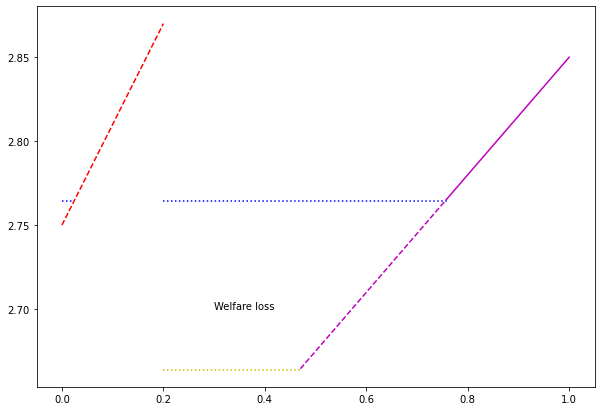

In [76]:
([sigma_c, uH_c, q_c, theta_c, u_c, tcL_c, tcH_c])= ([0.4, 12, 0.25, 3.5, 8, 0.03, 0.03])
plt.figure(figsize=(10, 7))
x = np.linspace(0,1,num=100)
x_1 = np.linspace(0.02,0.2,num=100)
x_2 = np.linspace(0,0.02, num=100)
x_3 = np.linspace(0.2,0.76, num=100)
x_4 = np.linspace(0.2,0.47, num=100)
x_5 = np.linspace(0.47, 0.76, num=100)
x_6 = np.linspace(0, 0.2, num=100)
x_7  = np.linspace(0.76, 1, num=100)
S_St_s = S_St.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c), (lambda_, 0.5)])
#plt.plot(x, S_St_s, '--y')
S_Sep_s = lambdify(['alpha'],S_Sep.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c), (lambda_, 0.5)]))
plt.plot(x_6, S_Sep_s(x_6), '--r')
S_PP_s = lambdify(['alpha'],S_PP.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c), (lambda_, 0.5)]))
plt.plot(x_5, S_PP_s(x_5), '--m')
plt.plot(x_7, S_PP_s(x_7), 'm')
S_Dep_s = S_Dep.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c), (lambda_, 0.5)])
#plt.plot(x, S_Dep_s(x), '--k')
S_Dep_s= S_Dep_s* np.ones_like(x)  # Constant value 3 for the range
plt.plot(x_4, S_Dep_s, 'y:')
S_St_s= S_St_s* np.ones_like(x)  # Constant value 3 for the range
plt.plot(x_2, S_St_s, 'b:')
plt.plot(x_3, S_St_s, 'b:')
plt.text(.3, 2.7, "Welfare loss")
#print(S_St_s)
#print(S_Dep_s)

### Payoff of the lending bank when stablecoins are and are not available, $\lambda = 0.5$

In [1]:
([sigma_c, uH_c, q_c, theta_c, u_c, tcL_c, tcH_c])= ([0.4, 12, 0.25, 3.5, 8, 0.03, 0.03])
plt.figure(figsize=(10, 7))
x = np.linspace(0,1,num=100)


B_Sep_s = B_Sep.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c), (lambda_, 0.7)])
B_Sep_s = B_Sep_s*np.ones_like(x)
plt.plot(x_6, B_Sep_s, 'r')

B_PP_s = lambdify(['alpha'],B_PP.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c), (lambda_, 0.7)]))
plt.plot(x_5, B_PP_s(x_5), '--m')
plt.plot(x_7, B_PP_s(x_7), 'm')
B_Dep_s = B_Dep.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c), (lambda_, 0.7)])
B_Dep_s = B_Dep_s*np.ones_like(x)
plt.plot(x_4, B_Dep_s, 'y--')

B_St_s = B_St.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c), (lambda_, 0.7)])
B_St_s = B_St_s*np.ones_like(x)
plt.plot(x_3, B_St_s, 'b')



NameError: name 'plt' is not defined

### Total welfare, $\lambda = 0.5$, parameter changed to look like Toni's paper

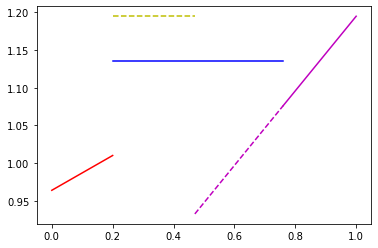

In [89]:
W_Dep_s = B_Dep.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c), (lambda_, 0.5)]) + S_Dep.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c), (lambda_, 0.5)])
W_Dep_s = W_Dep_s*np.ones_like(x)
W_Sep_s = B_Sep.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c), (lambda_, 0.5)]) + S_Sep.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c), (lambda_, 0.5)])
W_Sep_s = lambdify(['alpha'], W_Sep_s)
W_PP_s = S_PP.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c), (lambda_, 0.5)]) + B_PP.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c), (lambda_, 0.5)])
W_PP_s = lambdify(['alpha'], W_PP_s)
W_St_s = B_St.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c), (lambda_, 0.5)]) + S_Dep.subs([(uH, uH_c), (sigma, sigma_c), (q, q_c), (theta, theta_c), (u, u_c), (tcL, tcL_c), (tcH, tcH_c), (lambda_, 0.5)])
W_St_s = W_St_s*np.ones_like(x)
plt.plot(x_6, W_Sep_s(x_6), 'r')
plt.plot(x_4, W_Dep_s, 'y--')
plt.plot(x_5, W_PP_s(x_5), 'm--')
plt.plot(x_7, W_PP_s(x_7), 'm')
plt.plot(x_3, W_St_s, 'b')


In [91]:
W_Sep = B_Sep + B_Sep
W_St = B_St + S_St
W_PP = B_PP+S_PP
W_Dep = S_Dep +B_Dep
print(W_Dep)
print(W_St)

lambda*(lambda*sigma - q*sigma*theta + q*sigma*u - q*sigma*uH + q*sigma - 0.0249999999999999*q*theta - q*u + q*uH - sigma*u + u) - 1.0*(1.0*lambda**2*sigma + lambda*(-1.0*q*sigma*theta + 1.0*q*sigma*u - 1.0*q*sigma*uH + 1.0*q*sigma - 0.025*q*theta - 1.0*q*u + 1.0*q*uH - 1.0*sigma*u - 1.0*sigma + 1.0*u) + 1.0*q*sigma*theta - 1.0*q*sigma*u + 1.0*q*sigma*uH - 1.0*q*sigma - 1.0*q*theta + 1.0*q*u - 1.0*q*uH + 1.0*q + 1.0*sigma*u - 1.0*u + 1.0)
q*(theta*(1 - lambda) - 1) + q*(-(1 - lambda)*(1 - tcL)*(lambda*sigma + u*(1 - sigma)) + (1 - tcH)*(lambda*sigma - sigma*(theta - 1) + uH*(1 - sigma))) + q*(lambda*theta + (1 - lambda)*(1 - tcL)*(lambda*sigma + u*(1 - sigma)) - 1) + (1 - q)*(-(1 - lambda)*(1 - tcL)*(lambda*sigma + u*(1 - sigma)) + (1 - tcL)*(lambda*sigma + u*(1 - sigma))) + (1 - q)*((1 - lambda)*(1 - tcL)*(lambda*sigma + u*(1 - sigma)) - 1)


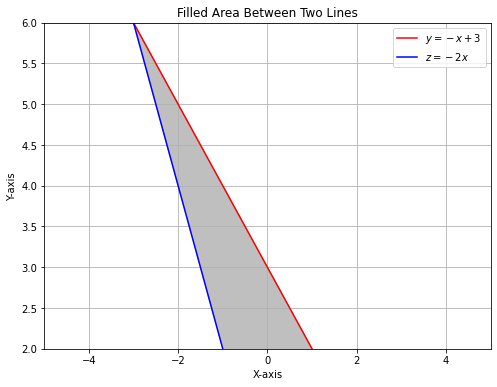

In [128]:
import numpy as np
import matplotlib.pyplot as plt

# Define x values
x = np.linspace(-3, 5, 400)  # Adjust range to include the intersection
a = symbols('a')
# Define the two functions
y_1 = -a + 3
y_1 = lambdify([a],y_1)
z = -2*a
z = lambdify([a],z)
# Define limits for y-axis
y_min, y_max = 2, 6

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(x, y_1(x), 'r', label=r'$y = -x + 3$')
plt.plot(x, z(x), 'b', label=r'$z = -2x$')

# Fill the area between the two lines within y-axis bounds
plt.fill_between(x, y_1(x), z(x), where=(y_1(x) >= y_min) & (y_1(x) <= y_max), color='gray', alpha=0.5)

# Labels and title
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Filled Area Between Two Lines')
plt.axis([-5, 5, -5, 5])
# Y-axis limits
plt.ylim(y_min, y_max)

# Legend
plt.legend()

# Show plot
plt.grid(True)
plt.show()


In [126]:
St_Sep

array([0.25      , 0.25757576, 0.26515152, 0.27272727, 0.28030303,
       0.28787879, 0.29545455, 0.3030303 , 0.31060606, 0.31818182,
       0.32575758, 0.33333333, 0.34090909, 0.34848485, 0.35606061,
       0.36363636, 0.37121212, 0.37878788, 0.38636364, 0.39393939,
       0.40151515, 0.40909091, 0.41666667, 0.42424242, 0.43181818,
       0.43939394, 0.4469697 , 0.45454545, 0.46212121, 0.46969697,
       0.48072403, 0.49201135, 0.50330342, 0.51460025, 0.52590183,
       0.53720818, 0.5485193 , 0.55983521, 0.57115589, 0.58248137,
       0.59381164, 0.60514672, 0.61648661, 0.62783131, 0.63918083,
       0.65053518, 0.66189437, 0.67325839, 0.68462726, 0.69600098,
       0.70737956, 0.71876301, 0.73015133, 0.74154452, 0.7529426 ,
       0.76434556, 0.77575343, 0.78716619, 0.79858387, 0.81000646,
       0.82143397, 0.8328664 , 0.84430378, 0.85574609, 0.86719335,
       0.87864556, 0.89010274, 0.90156487, 0.91303199, 0.92450408,
       0.93598116, 0.94746322, 0.95895029, 0.97044237, 0.98193

In [131]:
St_Dep

array([0.25, 0.25757575757575757, 0.26515151515151514, 0.2727272727272727,
       0.2803030303030303, 0.2878787878787879, 0.29545454545454547,
       0.30303030303030304, 0.3106060606060606, 0.3181818181818182,
       0.3257575757575758, 0.33333333333333337, 0.34090909090909094,
       0.3484848484848485, 0.3560606060606061, 0.36363636363636365,
       0.3712121212121212, 0.3787878787878788, 0.38636363636363635,
       0.3939393939393939, 0.40151515151515155, 0.40909090909090906,
       0.4166666666666667, 0.42424242424242425, 0.4318181818181818,
       0.4393939393939394, 0.446969696969697, 0.4545454545454546,
       0.46212121212121215, 0.4696969696969697, 0.4772727272727273,
       0.48484848484848486, 0.49242424242424243, 0.5, 0.5075757575757576,
       0.5151515151515151, 0.5227272727272727, 0.5303030303030303,
       0.5378787878787878, 0.5454545454545454, 0.5530303030303031,
       0.5606060606060607, 0.5681818181818181, 0.5757575757575758,
       0.5833333333333334, 0.590909090

In [133]:
Dep = Dep* np.ones_like(y)
Dep

array([0.76246672, 0.76246672, 0.76246672, 0.76246672, 0.76246672,
       0.76246672, 0.76246672, 0.76246672, 0.76246672, 0.76246672,
       0.76246672, 0.76246672, 0.76246672, 0.76246672, 0.76246672,
       0.76246672, 0.76246672, 0.76246672, 0.76246672, 0.76246672,
       0.76246672, 0.76246672, 0.76246672, 0.76246672, 0.76246672,
       0.76246672, 0.76246672, 0.76246672, 0.76246672, 0.76246672,
       0.76246672, 0.76246672, 0.76246672, 0.76246672, 0.76246672,
       0.76246672, 0.76246672, 0.76246672, 0.76246672, 0.76246672,
       0.76246672, 0.76246672, 0.76246672, 0.76246672, 0.76246672,
       0.76246672, 0.76246672, 0.76246672, 0.76246672, 0.76246672,
       0.76246672, 0.76246672, 0.76246672, 0.76246672, 0.76246672,
       0.76246672, 0.76246672, 0.76246672, 0.76246672, 0.76246672,
       0.76246672, 0.76246672, 0.76246672, 0.76246672, 0.76246672,
       0.76246672, 0.76246672, 0.76246672, 0.76246672, 0.76246672,
       0.76246672, 0.76246672, 0.76246672, 0.76246672, 0.76246